<a href="https://colab.research.google.com/github/usq0/sem_dml_workbook/blob/main/SEM_OLS_DML_Robustness_Workbook_v7_1_public_release.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEM → OLS → DML Robustness Workbook v7.1 (Public Release)

**Paper title:** *From SEM to Robustness Analysis: Using OLS and Double Machine Learning to Re-examine Digital Customer Intimacy in FinTech*

This public-release workbook is the executable companion to the paper. It demonstrates a staged post-SEM robustness workflow for business and information systems survey research.

The default workflow is:

1. specify the initial conceptual model and refine the measurement model using item, reliability, validity, and fit evidence;
2. estimate the **robustness-baseline SEM model**, where the refined measurement model is combined with the full theory-specified structural path system;
3. extract SEM factor scores and compute mean composite scores;
4. run OLS robustness checks on the robustness-baseline structural paths;
5. run DML-style robustness checks using RF, GBM, and SVM nuisance learners;
6. compare SEM, OLS, DML, score-sensitivity, learner-sensitivity, reverse-diagnostic, and theory evidence before making final structural model refinement decisions.

The notebook intentionally presents a single default public-release workflow. Structural path decisions are treated as end-of-workflow judgements informed by theory, SEM results, OLS results, DML results, learner sensitivity, score sensitivity, and diagnostic checks.

**Version 7.1:** Updates the workbook terminology to use the robustness-baseline SEM model, clarifies the distinction between measurement refinement and final structural path evaluation, and adds an explicit SEM endogenous-construct $R^2$ export.


## Table of contents

0. Conceptual model, constructs, variables, and indicators  
1. Setup, paths, reproducibility, and public-release settings  
2. Data loading and observed-data notation  
3. Construct specification and item-diagnostic decisions  
4. Reliability, redundancy, and item diagnostics  
5. Robustness-baseline SEM model specification and estimation  
6. SEM results: path estimates, fit indices, explained variance, and diagram  
7. Construct-score datasets: SEM factor scores and mean composite scores  
8. OLS robustness checks for the robustness-baseline structural paths  
9. Master DML-style robustness table: all score types and learners  
10. Learner-sensitivity tables derived from the master DML table  
11. Reverse-direction diagnostic checks  
12. Integrated SEM–OLS–DML robustness summary  
13. Reporting guidance and public-release checklist  
14. Exporting reproducible tables and figures


## Method-stage map

The public-release workflow uses eight method stages. These stages deliberately separate **measurement refinement** from **final structural path evaluation**. Indicators and measurement factors may be refined before the robustness analysis, but theory-specified structural paths are not removed immediately after SEM estimation. Final structural model refinement decisions are made only after all evidence has been reviewed.

| Stage | Label | Purpose |
|---|---|---|
| Stage 1 | Initial conceptual model and item diagnostics | Screen constructs, indicators, reliability, redundancy, and documented item-level decisions. |
| Stage 2 | Measurement-model refinement | Refine indicators or measurement factors where justified so that the latent constructs are empirically defensible. |
| Stage 3 | Robustness-baseline SEM estimation | Estimate the refined measurement model together with the full theory-specified structural path system before final structural path evaluation. |
| Stage 4 | Construct-score construction | Extract SEM factor scores and compute mean composite scores from the refined measurement model. |
| Stage 5 | SEM-to-regression path translation | Translate each robustness-baseline SEM path into path-level OLS and DML-style specifications with outcome $Y$, focal predictor $D$, and controls $\mathbf{X}$. |
| Stage 6 | OLS robustness benchmark | Re-estimate robustness-baseline SEM paths using conventional robust OLS on construct scores. |
| Stage 7 | DML-style robustness and sensitivity checks | Re-estimate robustness-baseline SEM paths using DML-style residualisation with RF, GBM, and SVM nuisance learners, and run selected reverse-direction diagnostics. |
| Stage 8 | Integrated robustness interpretation and final structural path evaluation | Compare SEM, OLS, DML, score-sensitivity, learner-sensitivity, reverse-diagnostic, and theory evidence before making final structural model refinement decisions. |


## 0 Conceptual model, constructs, variables, and indicators [Paper context]

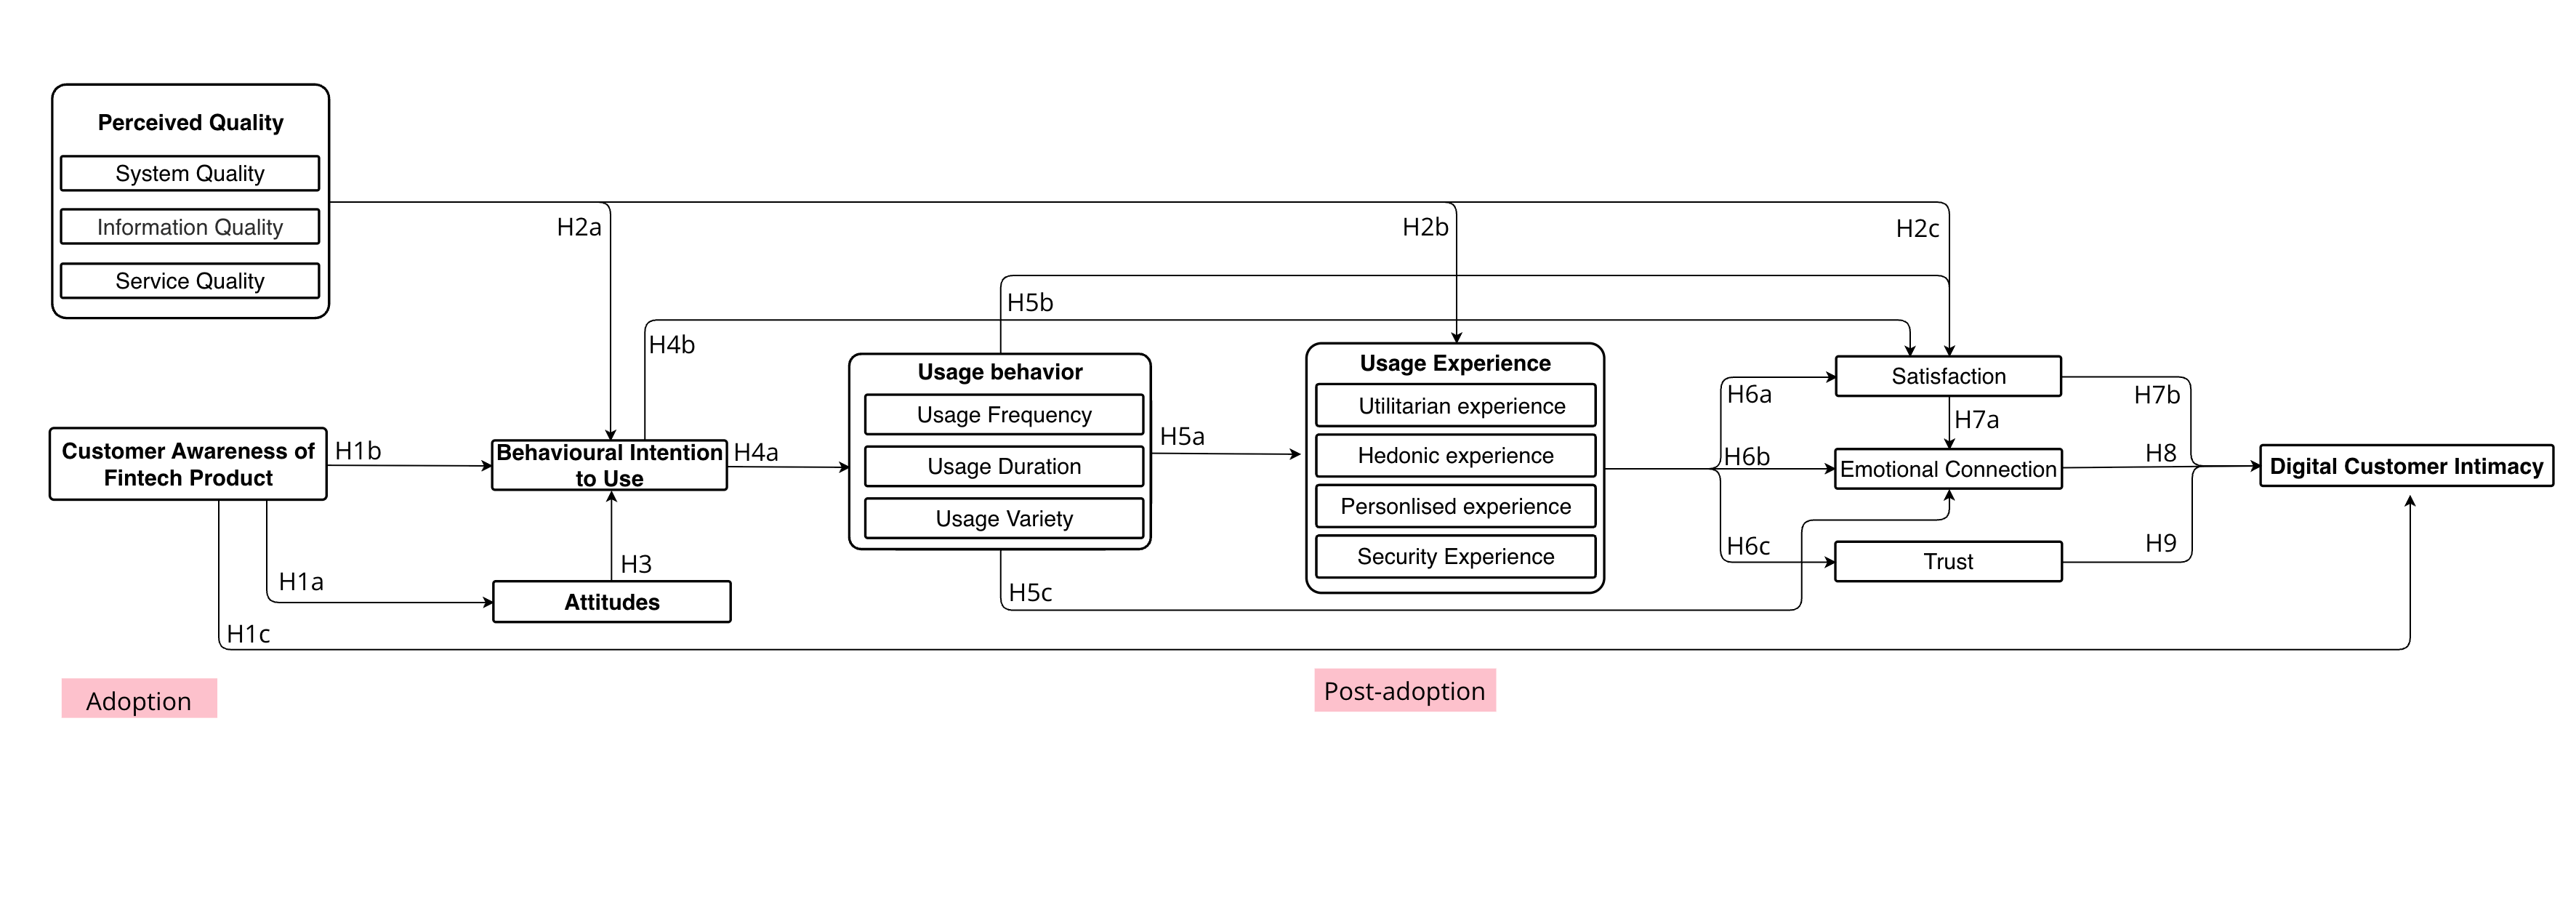

### 0.1 Construct and variable definitions

This workbook uses a survey-based SEM model of Digital Customer Intimacy in FinTech services. The model contains first-order latent constructs, second-order latent constructs, and one observed categorical contextual variable.

### Main theoretical roles of constructs

**Independent variables**

* Perceived Quality (PQ): second-order latent construct
* Customer Awareness (CA): first-order latent construct

**Mediating variables**

* Attitude (AT)
* Behavioural Intention to Use (BI)
* Usage Behaviour (UB)
* Usage Experience (UX): second-order latent construct
* Satisfaction (SA)
* Trust (TR)
* Emotional Connection (EC)

**Dependent variable**

* Digital Customer Intimacy (DCI)

**Observed categorical contextual/control variable**

* FinTech Type (FT)

In the SEM model, FinTech Type is not treated as a latent construct. It is an observed categorical variable used to define service-context groups and to support control or subgroup-based robustness checks.

### Second-order latent constructs

**Perceived Quality (PQ)** is inferred from three first-order quality dimensions:

* System Quality (PQ_SY), measured by PQ_SY1 to PQ_SY3
* Information Quality (PQ_IQ), measured by PQ_IQ1 to PQ_IQ3
* Service Quality (PQ_SQ), measured by PQ_SQ1 to PQ_SQ3

**Usage Experience (UX)** is inferred from four first-order experience dimensions:

* Utilitarian Experience (UX_UE), measured by UX_UE1 to UX_UE2
* Hedonic Experience (UX_HE), measured by UX_HE1 to UX_HE2
* Personalised Experience (UX_PE), measured by UX_PE1 to UX_PE2
* Security Experience (UX_SE), measured by UX_SE1 to UX_SE2

### First-order latent constructs

The remaining first-order latent constructs are measured directly by their observed survey indicators:

* Customer Awareness (CA), measured by CA1 to CA3
* Attitude (AT), measured by AT1 to AT2
* Behavioural Intention to Use (BI), measured by BI1 to BI2
* Usage Behaviour (UB), measured by Usage Frequency (UB_UF) and Usage Duration (UB_UD)
* Satisfaction (SA), measured by SA1 to SA2
* Trust (TR), measured by TR1 to TR2
* Emotional Connection (EC), measured by EC1 to EC3
* Digital Customer Intimacy (DCI), measured by DCI1 to DCI5

During model refinement, selected indicators may be removed, retained, or combined according to the documented SEM diagnostic decisions. For example, the derived indicator `DCI2_3_avg` is created by averaging DCI2 and DCI3.

### FinTech Type and dataframe objects

FinTech Type is an observed categorical variable identifying the type of FinTech service used by each respondent. In this workbook, it is used to create full-sample and subgroup datasets:

* `df_full`: the full analysis dataset including all FinTech types
* `df1`: the online-payment subgroup dataset
* `df_full_ex1`: the full analysis dataset excluding the online-payment subgroup

Conceptually:

$$
\texttt{df_full}
=
\text{all FinTech types},
$$

$$
\texttt{df1}
=
\text{online-payment respondents only},
$$

and:

$$
\texttt{df_full_ex1}
=
\texttt{df_full}
\setminus
\texttt{df1}.
$$

These dataframe objects are used to reproduce the original model-refinement checks and to make the sample structure explicit.


### 0.2 Notes on dataset

### Full-sample analysis and subgroup diagnostic datasets

The main analyses in this workbook are conducted using the full survey dataset. The SEM model fitting, SEM factor-score extraction, composite-score construction, OLS robustness checks, DML-style robustness checks, and learner-sensitivity checks are all based on the full working dataframe.

In the code, the full working dataframe is created as:

```python
df = df_raw.copy()
df_full = df.copy()
```

The main SEM model is fitted using `df`, and the downstream OLS and DML-style analyses use construct-score datasets derived from `df`.

The subgroup datasets `df1` and `df_full_ex1` are used only for selected model-refinement diagnostics, such as reliability and redundancy checks across FinTech service contexts. They are not used as the primary sample for the main SEM, OLS, or DML-style robustness results.

Therefore, unless otherwise stated, the reported SEM–OLS–DML results should be interpreted as full-sample results.


## 1 Setup, paths, reproducibility, and public-release settings [Pre-stage setup]

### 1.1 Reproducibility and runtime-state warning

In [ ]:
!pip install semopy pandas numpy scipy scikit-learn statsmodels matplotlib networkx openpyxl -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 4.9 MB/s eta 0:00:00


In [ ]:
import os
import sys
import platform
import itertools
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import networkx as nx

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
import sklearn
import statsmodels

from semopy import Model, calc_stats

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

# Reproducibility settings for OLS/DML-style robustness.
# HC1 and RF(50, leaf=5) are used consistently across all RF-DML outputs.
ROBUST_COV_TYPE = 'HC1'
DML_N_ESTIMATORS = 50
DML_MIN_SAMPLES_LEAF = 5
DML_N_SPLITS = 3
DML_RANDOM_STATE = 42


## 2 Data loading and observed-data notation [Input to Stages 1–8]

SEM is used as the primary theory-driven latent-variable model. OLS and DML-style checks are used as supplementary robustness analyses to examine whether the robustness-baseline SEM paths remain stable under alternative modelling assumptions.

The cleaned FinTech survey dataset contains 411 respondent observations and 42 observed variables. In the notation used in the paper, these dimensions are represented as:

$$
N = 411,
\quad
P = 42.
$$

The observed variables for respondent $i$ are collected in the respondent-level vector $\mathbf{Z}_i$:


$$
\mathbf{Z}_i =
\begin{bmatrix}
Z_{i1} & Z_{i2} & \cdots & Z_{iP}
\end{bmatrix}^{\prime},
\quad i = 1,\ldots,N.
$$

Stacking all respondent-level vectors gives the full observed data matrix:

$$
\mathbf{Z}
=
\begin{bmatrix}
\mathbf{Z}_1^{\prime} \\
\mathbf{Z}_2^{\prime} \\
\vdots \\
\mathbf{Z}_N^{\prime}
\end{bmatrix}
=
\begin{bmatrix}
Z_{11} & Z_{12} & \cdots & Z_{1P} \\
Z_{21} & Z_{22} & \cdots & Z_{2P} \\
\vdots & \vdots & \ddots & \vdots \\
Z_{N1} & Z_{N2} & \cdots & Z_{NP}
\end{bmatrix}
\in \mathbb{R}^{N \times P}
=
\mathbb{R}^{411 \times 42}.
$$

In the SEM stage, selected columns of $\mathbf{Z}$ are used as observed indicators for latent constructs such as perceived quality, attitude, behavioural intention, usage behaviour, user experience, satisfaction, trust, emotional connection, and digital customer intimacy. After SEM estimation, respondent-level factor scores are extracted and used as construct-level inputs for the downstream OLS and DML robustness analyses.


### 2.1 Note on $\boldsymbol{x}_i$, $\boldsymbol{y}_i$, and $\mathbf{Z}_i$

In the paper notation, $\boldsymbol{x}_i$ denotes the observed indicators associated with structurally exogenous latent constructs, and $\boldsymbol{y}_i$ denotes the observed indicators associated with structurally endogenous latent constructs. This distinction is useful for explaining the SEM measurement model.

However, in the actual Colab dataframe, the observed survey variables are not stored as two physically separate matrices. They are loaded together as one data matrix $\mathbf{Z}$. For respondent $i$, the full observed response vector is:

$$
\mathbf{Z}_i =
\begin{bmatrix}
Z_{i1} & Z_{i2} & \cdots & Z_{iP}
\end{bmatrix}^{\prime}.
$$

Conceptually, once the SEM model is specified, $\mathbf{Z}_i$ can be partitioned into the indicator vectors used in the measurement model:

$$
\mathbf{Z}_i =
\begin{bmatrix}
\boldsymbol{x}_i^{\prime} &
\boldsymbol{y}_i^{\prime}
\end{bmatrix}^{\prime}.
$$

This partition is therefore a modelling distinction rather than a separate data-loading step. In the Colab implementation, the same dataframe supplies all observed indicators, and the SEM model specification determines which columns are linked to exogenous and endogenous latent constructs.


In [ ]:
# Mount Google Drive when running in Colab. The try/except keeps the
# notebook runnable in local Jupyter environments as well.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print('Not running in Google Colab, or Google Drive mount skipped.')

OUTPUT_DIR = '/content/drive/My Drive/Colab Notebooks/dci/sem_ols_dml_outputs_v7_0_2'
if not IN_COLAB:
    OUTPUT_DIR = './sem_ols_dml_outputs_v7_0_2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Update this path if your cleaned dataset is stored elsewhere.
data_path = '/content/drive/My Drive/Colab Notebooks/dci/Cleaned_by_Fintech_Type.csv'
if not os.path.exists(data_path):
    fallback = 'Cleaned_by_Fintech_Type.csv'
    if os.path.exists(fallback):
        data_path = fallback

print('Input data path:', data_path)
print('Output directory:', OUTPUT_DIR)

df_raw = pd.read_csv(data_path)
print('Raw data shape:', df_raw.shape)
display(df_raw.head())

Mounted at /content/drive
Input data path: /content/drive/My Drive/Colab Notebooks/dci/Cleaned_by_Fintech_Type.csv
Output directory: /content/drive/My Drive/Colab Notebooks/dci/sem_ols_dml_outputs_v7_0_2
Raw data shape: (411, 42)


,Fintech Type,Response ID,CA1,CA2,CA3,PQ_SY1,PQ_SY2,PQ_SY3,PQ_IQ1,PQ_IQ2,PQ_IQ3,PQ_SQ1,PQ_SQ2,PQ_SQ3,AT1,AT2,BI1,BI2,UB_UF,UB_UD,UB_UV1,UB_UV2,UX_UE1,UX_UE2,UX_HE1,UX_HE2,UX_PE1,UX_PE2,UX_SE1,UX_SE2,SA1,SA2,TR1,TR2,EC1,EC2,EC3,DCI1,DCI2,DCI3,DCI4,DCI5
0,Mobile banking apps,1,2,3,3,5,5,5,5,5,3,3,3,5,5,5,5,4,4,1,5,3,5,5,3,4,3,3,2,2,3,3,4,4,4,5,5,4,4,4,4,4
1,Mobile banking apps,2,4,4,4,3,3,4,4,4,4,4,4,4,4,4,4,4,5,1,5,3,4,4,4,3,4,4,2,4,4,3,3,4,3,4,4,4,4,4,2,2
2,Mobile banking apps,4,3,3,3,4,2,2,1,2,3,1,1,1,1,1,1,1,3,3,3,3,2,3,3,1,2,3,3,4,2,1,3,3,2,3,2,3,2,3,3,3
3,Mobile banking apps,5,3,3,3,3,4,3,3,4,3,4,3,4,3,4,4,3,5,4,5,3,3,4,4,4,4,4,4,4,5,4,4,4,5,4,5,4,5,4,5,4
4,Mobile banking apps,6,3,2,3,3,2,3,3,4,3,4,4,4,4,3,4,4,5,4,3,2,5,5,4,4,3,3,4,4,4,5,4,4,4,4,4,3,5,5,4,4


## 3 Construct specification and item-diagnostic decisions [Stage 1: Item diagnostics]

In [ ]:
df = df_raw.copy()

# Derived indicator based on the documented model-refinement decision.
df['DCI2_3_avg'] = df[['DCI2', 'DCI3']].mean(axis=1)

# Recreate subgroup datasets used in the original exploratory checking.
fintech_types = df['Fintech Type'].dropna().unique()
sub_dfs = {
    f'df{i}': df[df['Fintech Type'] == t].copy()
    for i, t in enumerate(fintech_types)
}

print('FinTech type groups:')
for i, t in enumerate(fintech_types):
    print(f'df{i}: {t} | n={len(sub_dfs[f"df{i}"])}')

# Explicitly define df1 as the online-payment subgroup.
ONLINE_PAYMENT_LABEL = 'Online payment platforms'

df1 = df[df['Fintech Type'] == ONLINE_PAYMENT_LABEL].copy()
df_full = df.copy()
df_full_ex1 = df[df['Fintech Type'] != ONLINE_PAYMENT_LABEL].copy()

# Check sample sizes.
n_df1 = len(df1)
n_df_full = len(df_full)
n_df_full_ex1 = len(df_full_ex1)

print('\nDataset checks:')
print(f'df_full n     = {n_df_full}')
print(f'df1 n          = {n_df1}  ({ONLINE_PAYMENT_LABEL})')
print(f'df_full_ex1 n = {n_df_full_ex1}')
print(f'df1 + df_full_ex1 = {n_df1 + n_df_full_ex1}')

if n_df1 + n_df_full_ex1 == n_df_full:
    print('Check passed: df1 + df_full_ex1 = df_full')
else:
    print('Check failed: df1 + df_full_ex1 does not equal df_full')

print('\nFinTech Type counts in df1:')
print(df1['Fintech Type'].value_counts())

print('\nFinTech Type counts in df_full_ex1:')
print(df_full_ex1['Fintech Type'].value_counts())

print('\nDerived variable created: DCI2_3_avg')
display(df[['DCI2', 'DCI3', 'DCI2_3_avg']].head())


FinTech type groups:
df0: Mobile banking apps | n=270
df1: Online payment platforms | n=68
df2: Investment apps | n=32
df3: Budgeting tools  | n=11
df4: Cryptocurrency platforms | n=9
df5: Insurance technology | n=8
df6: Lending/Financing platforms | n=13

Dataset checks:
df_full n     = 411
df1 n          = 68  (Online payment platforms)
df_full_ex1 n = 343
df1 + df_full_ex1 = 411
Check passed: df1 + df_full_ex1 = df_full

FinTech Type counts in df1:
Fintech Type
Online payment platforms    68
Name: count, dtype: int64

FinTech Type counts in df_full_ex1:
Fintech Type
Mobile banking apps            270
Investment apps                 32
Lending/Financing platforms     13
Budgeting tools                 11
Cryptocurrency platforms         9
Insurance technology             8
Name: count, dtype: int64

Derived variable created: DCI2_3_avg


,DCI2,DCI3,DCI2_3_avg
0,4,4,4.0
1,4,4,4.0
2,2,3,2.5
3,5,4,4.5
4,5,5,5.0


### 3.1 Original and retained item specifications

In [ ]:
constructs_original = {
    'CA': ['CA1', 'CA2', 'CA3'],
    'PQ_SY': ['PQ_SY1', 'PQ_SY2', 'PQ_SY3'],
    'PQ_IQ': ['PQ_IQ1', 'PQ_IQ2', 'PQ_IQ3'],
    'PQ_SQ': ['PQ_SQ1', 'PQ_SQ2', 'PQ_SQ3'],
    'AT': ['AT1', 'AT2'],
    'BI': ['BI1', 'BI2'],
    'UB_UF_UD': ['UB_UF', 'UB_UD'],
    'UB_UV': ['UB_UV1', 'UB_UV2'],
    'UX_UE': ['UX_UE1', 'UX_UE2'],
    'UX_HE': ['UX_HE1', 'UX_HE2'],
    'UX_PE': ['UX_PE1', 'UX_PE2'],
    'UX_SE': ['UX_SE1', 'UX_SE2'],
    'SA': ['SA1', 'SA2'],
    'TR': ['TR1', 'TR2'],
    'EC': ['EC1', 'EC2', 'EC3'],
    'DCI_original': ['DCI1', 'DCI2', 'DCI3', 'DCI4', 'DCI5']
}

constructs_final = {
    'CA': ['CA1', 'CA2', 'CA3'],
    'PQ_SY': ['PQ_SY1', 'PQ_SY2', 'PQ_SY3'],
    'PQ_IQ': ['PQ_IQ1', 'PQ_IQ2', 'PQ_IQ3'],
    'PQ_SQ': ['PQ_SQ1', 'PQ_SQ2', 'PQ_SQ3'],
    'AT': ['AT1', 'AT2'],
    'BI': ['BI1', 'BI2'],
    'UB': ['UB_UF', 'UB_UV2'],
    'UX_PE': ['UX_PE1', 'UX_PE2'],
    'UX_SE': ['UX_SE1', 'UX_SE2'],
    'SA': ['SA1', 'SA2'],
    'TR': ['TR1', 'TR2'],
    'EC': ['EC1', 'EC2', 'EC3'],
    'DCI': ['DCI1', 'DCI2_3_avg', 'DCI5']
}

decision_log = pd.DataFrame([
    {'Area': 'DCI redundancy', 'Decision': 'Drop DCI4 and merge DCI2 + DCI3 as DCI2_3_avg', 'Reason': 'DCI2/DCI3/DCI4/DCI5 had repeated correlations above 0.8'},
    {'Area': 'UX item-set refinement', 'Decision': 'Drop UX_UE and UX_HE; retain UX_PE and UX_SE', 'Reason': 'UX_UE and UX_HE showed weaker reliability/alignment with fintech service context'},
    {'Area': 'UB item-set refinement', 'Decision': 'Drop UB_UV1 and UB_UD; retain UB_UF and UB_UV2', 'Reason': 'UB_UV1 is binary; UB_UD was weaker and more context-dependent'},
    {'Area': 'Robustness framing', 'Decision': 'Use OLS and DML after SEM', 'Reason': 'Additional robustness checks; not replacements for SEM'},
    {'Area': 'Public-release workflow', 'Decision': 'Carry the robustness-baseline SEM model into OLS and DML before any structural path-retention decision', 'Reason': 'Final path decisions should consider SEM, OLS, DML, learner sensitivity, theory, and parsimony together'}
])
display(decision_log)

,Area,Decision,Reason
0,DCI redundancy,Drop DCI4 and merge DCI2 + DCI3 as DCI2_3_avg,DCI2/DCI3/DCI4/DCI5 had repeated correlations ...
1,UX item-set refinement,Drop UX_UE and UX_HE; retain UX_PE and UX_SE,UX_UE and UX_HE showed weaker reliability/alig...
2,UB item-set refinement,Drop UB_UV1 and UB_UD; retain UB_UF and UB_UV2,UB_UV1 is binary; UB_UD was weaker and more co...
3,Robustness framing,Use OLS and DML after SEM,Additional robustness checks; not replacements...
4,Public-release workflow,Carry the robustness-baseline SEM model into O...,"Final path decisions should consider SEM, OLS,..."


### 3.2 Pre-SEM item and construct screening

## 4 Reliability, redundancy, and item diagnostics [Stage 1: Item diagnostics]

These checks are not SEM by themselves. They provide **evidence for measurement refinement** before the robustness-baseline SEM model is estimated.

Useful rules of thumb:

- Cronbach's alpha around 0.70 or above is often treated as acceptable, although context matters.
- Very high inter-item correlations, especially above 0.80, may indicate redundancy.
- Corrected item-total correlations below about 0.30 may suggest weak item fit.

In [ ]:
def cronbach_alpha(data, items):
    x = data[items].dropna().astype(float)
    k = len(items)
    if k < 2 or len(x) < 3:
        return np.nan
    item_vars = x.var(axis=0, ddof=1)
    total_var = x.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


def avg_inter_item_corr(data, items):
    if len(items) < 2:
        return np.nan
    corr = data[items].dropna().astype(float).corr()
    vals = [corr.loc[a, b] for a, b in itertools.combinations(items, 2)]
    return np.nanmean(vals)


def citc_summary(data, items):
    x = data[items].dropna().astype(float)
    out = {}
    for item in items:
        rest = [i for i in items if i != item]
        out[item] = x[item].corr(x[rest].sum(axis=1)) if rest else np.nan
    return '; '.join([f'{k}={v:.3f}' if pd.notna(v) else f'{k}=NA' for k, v in out.items()])

reliability_rows = []
for ds_name, dset in {'df1': df1, 'df_full': df_full, 'df_full_ex1': df_full_ex1}.items():
    for construct, items in constructs_original.items():
        reliability_rows.append({
            'Dataset': ds_name,
            'Construct': construct,
            'Items': ', '.join(items),
            'Alpha': cronbach_alpha(dset, items),
            'Avg inter-item corr': avg_inter_item_corr(dset, items),
            'CITC summary': citc_summary(dset, items),
            'N': len(dset.dropna(subset=items))
        })

reliability_df = pd.DataFrame(reliability_rows)
display(reliability_df.round(3))

# Stage 1 final retained-item reliability table.
# This records the reliability of the item sets used in the final SEM, OLS, and DML-style analyses.
final_reliability_rows = []
for ds_name, dset in {'df_full': df_full}.items():
    for construct, items in constructs_final.items():
        final_reliability_rows.append({
            'Dataset': ds_name,
            'Construct': construct,
            'Items': ', '.join(items),
            'Alpha': cronbach_alpha(dset, items),
            'Avg inter-item corr': avg_inter_item_corr(dset, items),
            'CITC summary': citc_summary(dset, items),
            'N': len(dset.dropna(subset=items))
        })

final_reliability_df = pd.DataFrame(final_reliability_rows)
print('Final retained-item reliability table:')
display(final_reliability_df.round(3))


,Dataset,Construct,Items,Alpha,Avg inter-item corr,CITC summary,N
0,df1,CA,"CA1, CA2, CA3",0.787,0.557,CA1=0.618; CA2=0.670; CA3=0.612,68
1,df1,PQ_SY,"PQ_SY1, PQ_SY2, PQ_SY3",0.857,0.669,PQ_SY1=0.727; PQ_SY2=0.724; PQ_SY3=0.745,68
2,df1,PQ_IQ,"PQ_IQ1, PQ_IQ2, PQ_IQ3",0.867,0.690,PQ_IQ1=0.710; PQ_IQ2=0.804; PQ_IQ3=0.734,68
3,df1,PQ_SQ,"PQ_SQ1, PQ_SQ2, PQ_SQ3",0.860,0.677,PQ_SQ1=0.806; PQ_SQ2=0.734; PQ_SQ3=0.679,68
4,df1,AT,"AT1, AT2",0.886,0.796,AT1=0.796; AT2=0.796,68
5,df1,BI,"BI1, BI2",0.824,0.701,BI1=0.701; BI2=0.701,68
6,df1,UB_UF_UD,"UB_UF, UB_UD",0.519,0.351,UB_UF=0.351; UB_UD=0.351,68
7,df1,UB_UV,"UB_UV1, UB_UV2",0.790,0.657,UB_UV1=0.657; UB_UV2=0.657,68
8,df1,UX_UE,"UX_UE1, UX_UE2",0.575,0.411,UX_UE1=0.411; UX_UE2=0.411,68
9,df1,UX_HE,"UX_HE1, UX_HE2",0.713,0.556,UX_HE1=0.556; UX_HE2=0.556,68


Final retained-item reliability table:


,Dataset,Construct,Items,Alpha,Avg inter-item corr,CITC summary,N
0,df_full,CA,"CA1, CA2, CA3",0.744,0.492,CA1=0.518; CA2=0.599; CA3=0.601,411
1,df_full,PQ_SY,"PQ_SY1, PQ_SY2, PQ_SY3",0.778,0.538,PQ_SY1=0.640; PQ_SY2=0.623; PQ_SY3=0.580,411
2,df_full,PQ_IQ,"PQ_IQ1, PQ_IQ2, PQ_IQ3",0.784,0.550,PQ_IQ1=0.596; PQ_IQ2=0.669; PQ_IQ3=0.607,411
3,df_full,PQ_SQ,"PQ_SQ1, PQ_SQ2, PQ_SQ3",0.859,0.671,PQ_SQ1=0.776; PQ_SQ2=0.753; PQ_SQ3=0.676,411
4,df_full,AT,"AT1, AT2",0.803,0.672,AT1=0.672; AT2=0.672,411
5,df_full,BI,"BI1, BI2",0.828,0.707,BI1=0.707; BI2=0.707,411
6,df_full,UB,"UB_UF, UB_UV2",0.409,0.258,UB_UF=0.258; UB_UV2=0.258,411
7,df_full,UX_PE,"UX_PE1, UX_PE2",0.816,0.690,UX_PE1=0.690; UX_PE2=0.690,411
8,df_full,UX_SE,"UX_SE1, UX_SE2",0.829,0.714,UX_SE1=0.714; UX_SE2=0.714,411
9,df_full,SA,"SA1, SA2",0.887,0.798,SA1=0.798; SA2=0.798,411


In [ ]:
# Reproduce DCI redundancy checks used in the model-refinement process.
dci_items = ['DCI1', 'DCI2', 'DCI3', 'DCI4', 'DCI5']
redundancy_rows = []
for ds_name, dset in {'df1': df1, 'df_full': df_full, 'df_full_ex1': df_full_ex1}.items():
    corr = dset[dci_items].corr()
    for a, b in itertools.combinations(dci_items, 2):
        value = corr.loc[a, b]
        if value > 0.80:
            redundancy_rows.append({
                'Dataset': ds_name,
                'Redundant Pair': f'{a} & {b}',
                'Correlation': value,
                'Threshold': '> 0.8'
            })

redundancy_df = pd.DataFrame(redundancy_rows)
display(redundancy_df.round(3))

,Dataset,Redundant Pair,Correlation,Threshold
0,df1,DCI2 & DCI3,0.824,> 0.8
1,df1,DCI2 & DCI4,0.811,> 0.8
2,df1,DCI4 & DCI5,0.835,> 0.8
3,df_full,DCI2 & DCI3,0.807,> 0.8
4,df_full,DCI3 & DCI4,0.820,> 0.8
5,df_full,DCI4 & DCI5,0.807,> 0.8
6,df_full_ex1,DCI2 & DCI3,0.805,> 0.8
7,df_full_ex1,DCI3 & DCI4,0.827,> 0.8
8,df_full_ex1,DCI4 & DCI5,0.802,> 0.8


## 5 Robustness-baseline SEM model specification and estimation [Stages 2–3]

In [ ]:
ROBUSTNESS_BASELINE_SEM_MODEL_SPEC = '''
AT ~ CA + PQ
BI ~ AT + CA
UB ~ BI
UX ~ UB + PQ
SA ~ BI + UX + UB
TR ~ UB + SA
EC ~ UB + TR
DCI ~ EC + TR + CA

PQ_SY =~ PQ_SY1 + PQ_SY2 + PQ_SY3
PQ_IQ =~ PQ_IQ1 + PQ_IQ2 + PQ_IQ3
PQ_SQ =~ PQ_SQ1 + PQ_SQ2 + PQ_SQ3
CA =~ CA1 + CA2 + CA3
BI =~ BI1 + BI2
AT =~ AT1 + AT2
UB =~ UB_UF + UB_UV2
UX_PE =~ UX_PE1 + UX_PE2
UX_SE =~ UX_SE1 + UX_SE2
SA =~ SA1 + SA2
EC =~ EC1 + EC2 + EC3
TR =~ TR1 + TR2
DCI =~ DCI1 + DCI2_3_avg + DCI5
PQ =~ PQ_SY + PQ_IQ + PQ_SQ
UX =~ UX_PE + UX_SE
'''

# Optional expert-only alternative for private checking. The public-release
# narrative and outputs are organised around ROBUSTNESS_BASELINE_SEM_MODEL_SPEC.
ALTERNATIVE_RETAINED_SEM_MODEL_SPEC = '''
AT ~ PQ
BI ~ AT + CA
UB ~ BI
UX ~ UB + PQ
SA ~ BI + UX + UB
TR ~ UB + SA
EC ~ UB
DCI ~ EC + TR

PQ_SY =~ PQ_SY1 + PQ_SY2 + PQ_SY3
PQ_IQ =~ PQ_IQ1 + PQ_IQ2 + PQ_IQ3
PQ_SQ =~ PQ_SQ1 + PQ_SQ2 + PQ_SQ3
CA =~ CA1 + CA2 + CA3
BI =~ BI1 + BI2
AT =~ AT1 + AT2
UB =~ UB_UF + UB_UV2
UX_PE =~ UX_PE1 + UX_PE2
UX_SE =~ UX_SE1 + UX_SE2
SA =~ SA1 + SA2
EC =~ EC1 + EC2 + EC3
TR =~ TR1 + TR2
DCI =~ DCI1 + DCI2_3_avg + DCI5
PQ =~ PQ_SY + PQ_IQ + PQ_SQ
UX =~ UX_PE + UX_SE
'''

MODEL_SPECIFICATIONS = {
    'robustness_baseline_sem_model': {
        'label': 'Robustness-baseline SEM model',
        'description': 'Default public-release model estimated after measurement refinement and carried into OLS/DML robustness checks before final structural path evaluation.',
        'spec': ROBUSTNESS_BASELINE_SEM_MODEL_SPEC
    },
    'alternative_retained_model': {
        'label': 'Alternative retained model',
        'description': 'Expert-only optional model for private sensitivity checking; not used in the public-release narrative.',
        'spec': ALTERNATIVE_RETAINED_SEM_MODEL_SPEC
    }
}

# Public-release default. Change only for private sensitivity checking.
MODEL_VARIANT_TO_RUN = 'robustness_baseline_sem_model'

if MODEL_VARIANT_TO_RUN not in MODEL_SPECIFICATIONS:
    raise ValueError(f'Unknown MODEL_VARIANT_TO_RUN: {MODEL_VARIANT_TO_RUN}')

ACTIVE_MODEL_KEY = MODEL_VARIANT_TO_RUN
ACTIVE_MODEL_LABEL = MODEL_SPECIFICATIONS[ACTIVE_MODEL_KEY]['label']
ACTIVE_SEM_MODEL_SPEC = MODEL_SPECIFICATIONS[ACTIVE_MODEL_KEY]['spec']

print('Active model variant:', ACTIVE_MODEL_KEY)
print('Active model label:', ACTIVE_MODEL_LABEL)
print(MODEL_SPECIFICATIONS[ACTIVE_MODEL_KEY]['description'])

Active model variant: robustness_baseline_sem_model
Active model label: Robustness-baseline SEM model
Default public-release model estimated after measurement refinement and carried into OLS/DML robustness checks before final structural path evaluation.


### 5.1 SEM model estimation [Stages 2–3]

The default public-release model is the **robustness-baseline SEM model**. It is the theory-informed structural model that is carried forward into OLS and DML robustness checks.

The notebook contains an expert setting that can run an alternative retained specification for private checks. However, the public-release narrative, outputs, and table names are organised around the robustness-baseline SEM model.

In [ ]:
def stars_from_p(p):
    try:
        p = float(p)
    except Exception:
        return ''
    if np.isnan(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def fit_sem_model(model_name, model_spec, data):
    model = Model(model_spec)
    fit_result = model.fit(data)
    params = model.inspect()
    params['p_num'] = pd.to_numeric(params['p-value'], errors='coerce')
    params['sig'] = params['p_num'].apply(stars_from_p)
    stats = calc_stats(model)
    return model, fit_result, params, stats


sem_models = {}
sem_outputs = {}

print(f'Fitting SEM model: {ACTIVE_MODEL_KEY} ({ACTIVE_MODEL_LABEL})')
model, fit_result, params, stats = fit_sem_model(ACTIVE_MODEL_KEY, ACTIVE_SEM_MODEL_SPEC, df)
sem_models[ACTIVE_MODEL_KEY] = model
sem_outputs[ACTIVE_MODEL_KEY] = {'fit_result': fit_result, 'params': params, 'stats': stats}

print(fit_result)

Fitting SEM model: robustness_baseline_sem_model (Robustness-baseline SEM model)
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 2.838
Number of iterations: 82
Params: 0.038 1.102 0.924 0.215 0.085 0.934 0.261 0.182 2.380 -2.043 0.665 0.707 1.973 -0.014 1.112 -0.170 0.022 0.989 1.153 0.943 1.010 1.034 0.861 1.594 1.247 0.941 0.992 1.629 1.133 0.929 0.956 1.121 1.397 0.905 1.376 1.213 1.098 1.063 1.527 0.173 0.357 0.239 0.136 0.310 0.313 0.423 0.744 0.573 0.713 0.026 0.530 0.202 0.373 0.213 0.575 0.453 0.384 0.368 0.182 0.000 0.348 0.290 0.397 0.280 0.243 0.255 0.428 0.039 0.496 0.467 0.277 0.083 0.181 0.192 0.119 0.261 0.204 0.080 1.147 0.884 0.059 0.486 0.458 0.208 0.256 0.327 0.184


In [ ]:
MAIN_CONSTRUCTS = {'PQ', 'CA', 'AT', 'BI', 'UB', 'UX', 'SA', 'TR', 'EC', 'DCI'}

sem_structural_rows = []
for model_name, output in sem_outputs.items():
    params = output['params']
    structural = params[
        (params['op'] == '~') &
        (params['p_num'].notna()) &
        (params['lval'].isin(MAIN_CONSTRUCTS)) &
        (params['rval'].isin(MAIN_CONSTRUCTS))
    ].copy()
    structural['Model'] = model_name
    structural['Path'] = structural['rval'] + ' → ' + structural['lval']
    sem_structural_rows.append(structural[['Model', 'Path', 'lval', 'rval', 'Estimate', 'Std. Err', 'z-value', 'p-value', 'p_num', 'sig']])

sem_structural_all = pd.concat(sem_structural_rows, ignore_index=True)
display(sem_structural_all.round(6))

,Model,Path,lval,rval,Estimate,Std. Err,z-value,p-value,p_num,sig
0,robustness_baseline_sem_model,CA → AT,AT,CA,0.037876,0.062276,0.608203,0.543053,0.543053,n.s.
1,robustness_baseline_sem_model,PQ → AT,AT,PQ,1.102151,0.097567,11.296368,0.0,0.000000,***
2,robustness_baseline_sem_model,AT → BI,BI,AT,0.924247,0.063899,14.464177,0.0,0.000000,***
3,robustness_baseline_sem_model,CA → BI,BI,CA,0.214789,0.067149,3.198696,0.001381,0.001381,**
4,robustness_baseline_sem_model,BI → UB,UB,BI,0.084512,0.030119,2.80598,0.005016,0.005016,**
5,robustness_baseline_sem_model,UB → UX,UX,UB,0.933708,0.260818,3.579922,0.000344,0.000344,***
6,robustness_baseline_sem_model,PQ → UX,UX,PQ,0.260525,0.056964,4.573491,0.000005,0.000005,***
7,robustness_baseline_sem_model,BI → SA,SA,BI,0.182477,0.070746,2.579322,0.009899,0.009899,**
8,robustness_baseline_sem_model,UX → SA,SA,UX,2.380199,0.514307,4.62797,0.000004,0.000004,***
9,robustness_baseline_sem_model,UB → SA,SA,UB,-2.042860,0.68367,-2.988079,0.002807,0.002807,**


In [ ]:
fit_rows = []
for model_name, output in sem_outputs.items():
    vals = output['stats'].iloc[0].to_dict()
    row = {'Model': model_name}
    for key in ['DoF', 'chi2', 'chi2 p-value', 'CFI', 'TLI', 'RMSEA', 'AIC', 'BIC', 'LogLik']:
        row[key] = vals.get(key, np.nan)
    row['chi2/df'] = row['chi2'] / row['DoF'] if row.get('DoF') else np.nan
    fit_rows.append(row)

sem_fit_overview = pd.DataFrame(fit_rows)
display(sem_fit_overview.round(4))

,Model,DoF,chi2,chi2 p-value,CFI,TLI,RMSEA,AIC,BIC,LogLik,chi2/df
0,robustness_baseline_sem_model,441.0,1166.4208,0.0,0.9069,0.8953,0.0633,168.324,517.9416,2.838,2.6449


### 5.2 SEM explained variance ($R^2$) for endogenous constructs [Stage 3]

This step explicitly derives SEM $R^2$ values for endogenous constructs in the robustness-baseline SEM model. In a standardised SEM solution, the $R^2$ value for an endogenous construct is calculated as:

$$
R^2_j = 1 - \widehat{\psi}^{std}_{jj},
$$

where $\widehat{\psi}^{std}_{jj}$ is the standardised residual variance for construct $j$. These values are explanatory diagnostics for the robustness-baseline SEM model. They are not OLS $R^2$, DML nuisance-model $R^2$, or evidence of causal identification.


In [ ]:
def interpret_sem_r2(r2):
    if pd.isna(r2):
        return 'missing'
    if r2 < 0.25:
        return 'low explained variance'
    if r2 < 0.50:
        return 'modest explained variance'
    if r2 < 0.75:
        return 'substantial explained variance'
    if r2 < 0.90:
        return 'strong explained variance'
    return 'very high explained variance'


def derive_sem_endogenous_r2(model, model_key, model_label, main_constructs):
    """Derive SEM R² values from standardised residual variances.

    semopy does not always return an R² table directly. For a standardised
    SEM solution, the residual variance of an endogenous latent construct is
    1 - R². This function extracts rows such as AT ~~ AT from the standardised
    parameter table and calculates R² = 1 - standardised residual variance.
    """
    std_params = model.inspect(std_est=True).copy()
    std_estimate_col_candidates = ['Est. Std', 'Est.Std', 'Std. Estimate', 'Std Estimate', 'Estimate']
    std_col = next((col for col in std_estimate_col_candidates if col in std_params.columns), None)
    if std_col is None:
        raise ValueError(f'Could not find a standardised estimate column. Available columns: {list(std_params.columns)}')

    endogenous_constructs = sorted(
        set(std_params.loc[(std_params['op'] == '~') & (std_params['lval'].isin(main_constructs)), 'lval'])
    )

    rows = []
    for construct in endogenous_constructs:
        residual_rows = std_params[
            (std_params['op'] == '~~') &
            (std_params['lval'] == construct) &
            (std_params['rval'] == construct)
        ]
        if residual_rows.empty:
            std_resid_var = np.nan
            r2 = np.nan
            source_note = 'No standardised residual variance row found.'
        else:
            std_resid_var = pd.to_numeric(residual_rows.iloc[0][std_col], errors='coerce')
            r2 = 1 - std_resid_var if pd.notna(std_resid_var) else np.nan
            # Avoid tiny floating-point excursions outside the admissible range.
            if pd.notna(r2):
                r2 = min(max(float(r2), 0.0), 1.0)
            source_note = f'Derived from standardised residual variance row: {construct} ~~ {construct}.'

        rows.append({
            'Model key': model_key,
            'Model label': model_label,
            'Construct': construct,
            'Is endogenous': True,
            'Standardised residual variance': std_resid_var,
            'SEM R2': r2,
            'SEM R2 rounded': round(r2, 3) if pd.notna(r2) else np.nan,
            'Interpretation': interpret_sem_r2(r2),
            'Formula': 'R2 = 1 - standardised residual variance',
            'Source note': source_note
        })

    return pd.DataFrame(rows)


sem_endogenous_r2 = derive_sem_endogenous_r2(
    sem_models[ACTIVE_MODEL_KEY],
    ACTIVE_MODEL_KEY,
    ACTIVE_MODEL_LABEL,
    MAIN_CONSTRUCTS
)

print('SEM R² values for endogenous constructs in the robustness-baseline SEM model:')
display(sem_endogenous_r2.round(6))


SEM R² values for endogenous constructs in the robustness-baseline SEM model:


,Model key,Model label,Construct,Is endogenous,Standardised residual variance,SEM R2,SEM R2 rounded,Interpretation,Formula,Source note
0,robustness_baseline_sem_model,Robustness-baseline SEM model,AT,True,0.271919,0.728081,0.728,substantial explained variance,R2 = 1 - standardised residual variance,Derived from standardised residual variance ro...
1,robustness_baseline_sem_model,Robustness-baseline SEM model,BI,True,0.173069,0.826931,0.827,strong explained variance,R2 = 1 - standardised residual variance,Derived from standardised residual variance ro...
2,robustness_baseline_sem_model,Robustness-baseline SEM model,DCI,True,0.040280,0.959720,0.960,very high explained variance,R2 = 1 - standardised residual variance,Derived from standardised residual variance ro...
3,robustness_baseline_sem_model,Robustness-baseline SEM model,EC,True,0.393654,0.606346,0.606,substantial explained variance,R2 = 1 - standardised residual variance,Derived from standardised residual variance ro...
4,robustness_baseline_sem_model,Robustness-baseline SEM model,SA,True,0.119149,0.880851,0.881,strong explained variance,R2 = 1 - standardised residual variance,Derived from standardised residual variance ro...
5,robustness_baseline_sem_model,Robustness-baseline SEM model,TR,True,0.215850,0.784150,0.784,strong explained variance,R2 = 1 - standardised residual variance,Derived from standardised residual variance ro...
6,robustness_baseline_sem_model,Robustness-baseline SEM model,UB,True,0.934589,0.065411,0.065,low explained variance,R2 = 1 - standardised residual variance,Derived from standardised residual variance ro...
7,robustness_baseline_sem_model,Robustness-baseline SEM model,UX,True,0.334812,0.665188,0.665,substantial explained variance,R2 = 1 - standardised residual variance,Derived from standardised residual variance ro...


### 5.3 Interpretation of the robustness-baseline SEM model

At this stage, the SEM results are treated as the primary latent-variable evidence. They show how the theoretical paths behave when the measurement model, second-order constructs, and structural equations are estimated together.

No structural path is removed automatically at this point. Final structural path evaluation decisions should be made only after reviewing the SEM estimates, SEM fit, OLS benchmarks, DML robustness checks, learner sensitivity, and theoretical justification.

## 6 SEM results: path estimates, fit indices, and diagram [Stage 3: SEM structural model]

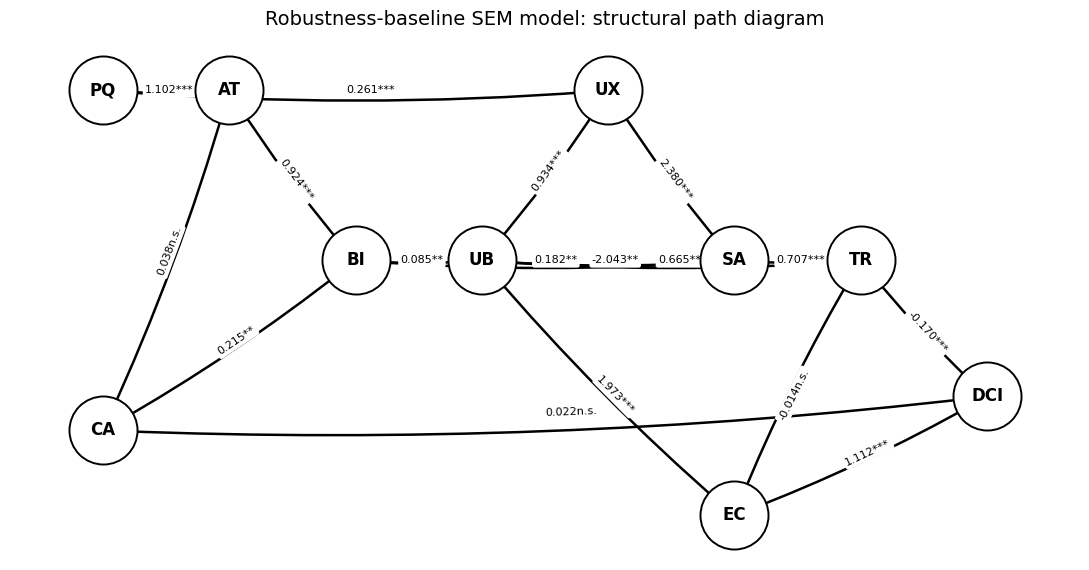

In [ ]:
def draw_path_diagram(edges, title, edge_labels=None, figsize=(11, 5.8)):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    pos = {
        'PQ': (0, 2), 'CA': (0, 0), 'AT': (1, 2), 'BI': (2, 1), 'UB': (3, 1),
        'UX': (4, 2), 'SA': (5, 1), 'TR': (6, 1), 'EC': (5, -0.5), 'DCI': (7, 0.2)
    }
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_size=2400, node_color='white', edgecolors='black', linewidths=1.4)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=18, width=1.8, connectionstyle='arc3,rad=0.04')
    if edge_labels:
        nx.draw_networkx_edge_labels(
            G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.53,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none')
        )
    plt.title(title, fontsize=14, pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


active_structural = sem_structural_all[sem_structural_all['Model'] == ACTIVE_MODEL_KEY].copy()
active_edges = list(zip(active_structural['rval'], active_structural['lval']))
edge_labels = {
    (row['rval'], row['lval']): f"{row['Estimate']:.3f}{row['sig']}"
    for _, row in active_structural.iterrows()
}

draw_path_diagram(
    active_edges,
    f'{ACTIVE_MODEL_LABEL}: structural path diagram',
    edge_labels=edge_labels
)

## 7 Construct-score datasets: SEM factor scores and mean composite scores [Stage 4: Construct-score construction]

### 7.1 SEM factor-score extraction

After the robustness-baseline SEM model is fitted, respondent-level latent construct scores are extracted using the SEM measurement and structural model. These scores are model-based estimates of the latent constructs, rather than simple averages of observed items.

For respondent $i$, the full observed response vector is $\mathbf{Z}_i$. The SEM estimates a respondent-level latent score vector:

$$
\widehat{\boldsymbol{\omega}}_i
=
\begin{bmatrix}
\widehat{\boldsymbol{\xi}}_i^{\prime} &
\widehat{\boldsymbol{\eta}}_i^{\prime}
\end{bmatrix}^{\prime},
$$

where $\widehat{\boldsymbol{\xi}}_i$ contains estimated scores for structurally exogenous latent constructs and $\widehat{\boldsymbol{\eta}}_i$ contains estimated scores for structurally endogenous latent constructs.

In the paper notation, the SEM factor-score extraction can be written as:

$$
\widehat{\boldsymbol{\omega}}_i
=
\mathbf{\Phi}_{\omega}
\boldsymbol{\Lambda}^{\prime}
\mathbf{\Sigma}(\widehat{\boldsymbol{\theta}})^{-1}
\mathbf{Z}_i.
$$

Here, $\widehat{\boldsymbol{\theta}}$ is the estimated SEM parameter vector, $\boldsymbol{\Lambda}$ is the factor-loading matrix, $\mathbf{\Sigma}(\widehat{\boldsymbol{\theta}})$ is the model-implied covariance matrix, and $\mathbf{\Phi}_{\omega}$ is the latent construct covariance matrix implied by the fitted SEM.

Stacking the extracted factor-score vectors for all $N$ respondents gives the SEM factor-score matrix:

$$
\widehat{\mathbf{F}}^{SEM}
=
\begin{bmatrix}
\widehat{\boldsymbol{\omega}}_1^{\prime} \\
\widehat{\boldsymbol{\omega}}_2^{\prime} \\
\vdots \\
\widehat{\boldsymbol{\omega}}_N^{\prime}
\end{bmatrix}
\in
\mathbb{R}^{N \times C},
$$

where $C$ is the number of latent construct scores extracted from the fitted SEM model.

In the Colab implementation, this corresponds to applying `predict_factors()` to the fitted SEM model.


In [ ]:
active_sem_model = sem_models[ACTIVE_MODEL_KEY]
factor_scores = active_sem_model.predict_factors(df)
print('Factor score columns:')
print(list(factor_scores.columns))
display(factor_scores.head())

Factor score columns:
['AT', 'BI', 'CA', 'DCI', 'EC', 'PQ', 'PQ_IQ', 'PQ_SQ', 'PQ_SY', 'SA', 'TR', 'UB', 'UX', 'UX_PE', 'UX_SE']


,AT,BI,CA,DCI,EC,PQ,PQ_IQ,PQ_SQ,PQ_SY,SA,TR,UB,UX,UX_PE,UX_SE
0,0.782699,0.643697,-0.128666,1.036796,0.917962,0.527954,0.579888,-0.038603,0.694771,-0.787119,-0.211095,0.151436,-0.216846,-0.133250,-1.391841
1,0.075938,0.110423,0.469516,0.537314,0.435458,0.044171,0.048516,0.278579,-0.021990,-0.443775,-0.330527,0.121960,-0.055693,0.631497,-0.441465
2,-2.363487,-2.651061,-0.327879,-0.184881,-0.308185,-1.723826,-1.893398,-2.459219,-1.579581,-2.124059,-1.261623,-0.050348,-0.645062,-0.427129,-0.480615
3,-0.263890,-0.309104,-0.102145,1.149304,1.085377,-0.304240,-0.334168,-0.116519,-0.339802,0.301291,0.233721,0.286449,0.346782,0.710945,0.288239
4,-0.274307,-0.125216,-0.322534,1.032285,0.897190,-0.388719,-0.426957,0.157789,-0.524316,0.246569,0.143802,0.179164,0.213381,-0.048324,0.220071


### 7.2 Composite-score construction

As a transparent benchmark, construct-level composite scores are also calculated directly from the retained observed indicators. Unlike SEM factor scores, composite scores do not use estimated factor loadings or the model-implied covariance structure. They are simple unweighted averages of the retained items.

For construct $c$, let the retained final indicator set be:

$$
\mathcal{I}_{c}^{(F)}
=
\left\{
j_1, j_2, \ldots, j_{J_c}
\right\},
$$

where $J_c$ is the number of retained indicators for construct $c$.

For respondent $i$, the composite score for construct $c$ is:

$$
\bar{Z}_{c,i}^{COMP}
=
\frac{1}{J_c}
\sum_{j \in \mathcal{I}_{c}^{(F)}}
Z_{ij}.
$$

Equivalently, if the retained item vector for respondent $i$ is $\mathbf{Z}_{c,i}^{(F)}$, then:

$$
\bar{Z}_{c,i}^{COMP}
=
\frac{1}{J_c}
\mathbf{1}_{J_c}^{\prime}
\mathbf{Z}_{c,i}^{(F)}.
$$

Stacking all construct-level composite scores gives the composite-score matrix:

$$
\mathbf{F}^{COMP}
=
\begin{bmatrix}
\bar{\mathbf{z}}_{1}^{COMP\prime} \\
\bar{\mathbf{z}}_{2}^{COMP\prime} \\
\vdots \\
\bar{\mathbf{z}}_{N}^{COMP\prime}
\end{bmatrix}
\in
\mathbb{R}^{N \times C}.
$$

Thus, the empirical analysis uses two parallel construct-score matrices: $\widehat{\mathbf{F}}^{SEM}$ for SEM factor scores and $\mathbf{F}^{COMP}$ for mean composite scores.

### Why two score types are used

The SEM factor-score matrix $\widehat{\mathbf{F}}^{SEM}$ preserves the fitted SEM measurement structure, including estimated factor loadings and model-implied relationships among constructs. The composite-score matrix $\mathbf{F}^{COMP}$ provides a simpler item-average benchmark.

The downstream OLS and DML robustness checks are therefore repeated using both score types:

$$
\widehat{\mathbf{F}}^{SEM}
\quad
\text{and}
\quad
\mathbf{F}^{COMP}.
$$

If a path remains stable under both scoring approaches, the result is less dependent on the way construct scores are calculated. If a path changes substantially across scoring approaches, the relationship should be interpreted more cautiously.

In [ ]:
# Composite scores based on the final retained items.
composite_item_map = {
    'PQ': ['PQ_SY1', 'PQ_SY2', 'PQ_SY3', 'PQ_IQ1', 'PQ_IQ2', 'PQ_IQ3', 'PQ_SQ1', 'PQ_SQ2', 'PQ_SQ3'],
    'CA': ['CA1', 'CA2', 'CA3'],
    'AT': ['AT1', 'AT2'],
    'BI': ['BI1', 'BI2'],
    'UB': ['UB_UF', 'UB_UV2'],
    'UX': ['UX_PE1', 'UX_PE2', 'UX_SE1', 'UX_SE2'],
    'SA': ['SA1', 'SA2'],
    'TR': ['TR1', 'TR2'],
    'EC': ['EC1', 'EC2', 'EC3'],
    'DCI': ['DCI1', 'DCI2_3_avg', 'DCI5']
}

composite_scores = pd.DataFrame(index=df.index)
for construct, items in composite_item_map.items():
    composite_scores[construct] = df[items].mean(axis=1)

construct_order = ['PQ', 'CA', 'AT', 'BI', 'UB', 'UX', 'SA', 'TR', 'EC', 'DCI']

# Factor score table: use SEM factor scores where available; fall back to composite scores if needed.
factor_score_table = pd.DataFrame(index=df.index)
for construct in construct_order:
    if construct in factor_scores.columns:
        factor_score_table[construct] = factor_scores[construct]
    else:
        factor_score_table[construct] = composite_scores[construct]

# Standardise both score sets so OLS and DML coefficients are easier to compare.
factor_score_z = pd.DataFrame(StandardScaler().fit_transform(factor_score_table), columns=construct_order, index=df.index)
composite_score_z = pd.DataFrame(StandardScaler().fit_transform(composite_scores[construct_order]), columns=construct_order, index=df.index)

factor_score_z['Fintech Type'] = df['Fintech Type']
composite_score_z['Fintech Type'] = df['Fintech Type']

print('Factor-score robustness dataset:')
display(factor_score_z.head())

print('Composite-score sensitivity dataset:')
display(composite_score_z.head())

Factor-score robustness dataset:


,PQ,CA,AT,BI,UB,UX,SA,TR,EC,DCI,Fintech Type
0,0.885243,-0.224237,1.132695,0.796857,0.628465,-0.569870,-0.993817,-0.308474,1.300216,1.333537,Mobile banking apps
1,0.074064,0.818264,0.109895,0.136697,0.506137,-0.146361,-0.560311,-0.483001,0.616789,0.691099,Mobile banking apps
2,-2.890415,-0.571422,-3.420355,-3.281853,-0.208946,-1.695219,-2.681841,-1.843615,-0.436517,-0.237796,Mobile banking apps
3,-0.510132,-0.178016,-0.381892,-0.382652,1.188775,0.911340,0.380411,0.341537,1.537344,1.478246,Mobile banking apps
4,-0.651783,-0.562106,-0.396967,-0.155010,0.743536,0.560765,0.311319,0.210139,1.270794,1.327736,Mobile banking apps


Composite-score sensitivity dataset:


,PQ,CA,AT,BI,UB,UX,SA,TR,EC,DCI,Fintech Type
0,0.893262,-0.438423,1.315168,0.571887,0.238099,-1.321799,-1.143169,0.055742,1.655884,1.119712,Mobile banking apps
1,0.090966,0.950339,0.179592,0.043695,0.820591,0.049203,-0.571585,-0.580644,0.608856,0.466712,Mobile banking apps
2,-2.636842,-0.091233,-3.227135,-3.125458,-0.344393,-0.636298,-2.857923,-1.217030,-0.787182,-0.023038,Mobile banking apps
3,-0.390412,-0.091233,-0.388196,-0.484497,0.820591,0.734704,0.571585,0.055742,1.655884,1.282962,Mobile banking apps
4,-0.550871,-0.438423,-0.388196,0.043695,0.238099,0.049203,0.571585,0.055742,0.957865,1.119712,Mobile banking apps


## 8 OLS robustness checks for the robustness-baseline SEM paths [Stages 5–6: Path-level setup and OLS benchmark]

The OLS stage translates each structural equation in the robustness-baseline SEM model into a conventional regression benchmark using construct scores. This does not replace SEM and does not reproduce SEM's treatment of measurement error. Its purpose is narrower: to check whether the direction and significance of the robustness-baseline SEM paths remain broadly consistent under a simpler regression framework.

### 8.1 OLS robustness checks using SEM factor scores and composite scores

### 8.2 Path-by-path OLS specification [Stage 5]

In [ ]:
def direction_from_estimate(x):
    if pd.isna(x):
        return 'missing'
    if x > 0:
        return 'positive'
    if x < 0:
        return 'negative'
    return 'zero'


OBSERVED_CONTROLS = ['Fintech Type']

# Path-level OLS/DML specification for the robustness-baseline SEM model.
# Co-predictors in the same SEM equation are included as controls when a focal
# predictor is estimated path by path. Downstream variables and mediators are
# not added as controls.
ROBUSTNESS_BASELINE_SEM_EQUATIONS = [
    {'Outcome': 'AT', 'Predictors': ['CA', 'PQ'], 'Focal': ['CA', 'PQ']},
    {'Outcome': 'BI', 'Predictors': ['AT', 'CA'], 'Focal': ['AT', 'CA']},
    {'Outcome': 'UB', 'Predictors': ['BI'], 'Focal': ['BI']},
    {'Outcome': 'UX', 'Predictors': ['UB', 'PQ'], 'Focal': ['UB', 'PQ']},
    {'Outcome': 'SA', 'Predictors': ['BI', 'UX', 'UB'], 'Focal': ['BI', 'UX', 'UB']},
    {'Outcome': 'TR', 'Predictors': ['UB', 'SA'], 'Focal': ['UB', 'SA']},
    {'Outcome': 'EC', 'Predictors': ['UB', 'TR'], 'Focal': ['UB', 'TR']},
    {'Outcome': 'DCI', 'Predictors': ['EC', 'TR', 'CA'], 'Focal': ['EC', 'TR', 'CA']},
]

ALTERNATIVE_RETAINED_EQUATIONS = [
    {'Outcome': 'AT', 'Predictors': ['PQ'], 'Focal': ['PQ']},
    {'Outcome': 'BI', 'Predictors': ['AT', 'CA'], 'Focal': ['AT', 'CA']},
    {'Outcome': 'UB', 'Predictors': ['BI'], 'Focal': ['BI']},
    {'Outcome': 'UX', 'Predictors': ['UB', 'PQ'], 'Focal': ['UB', 'PQ']},
    {'Outcome': 'SA', 'Predictors': ['BI', 'UX', 'UB'], 'Focal': ['BI', 'UX', 'UB']},
    {'Outcome': 'TR', 'Predictors': ['UB', 'SA'], 'Focal': ['UB', 'SA']},
    {'Outcome': 'EC', 'Predictors': ['UB'], 'Focal': ['UB']},
    {'Outcome': 'DCI', 'Predictors': ['EC', 'TR'], 'Focal': ['EC', 'TR']},
]

EQUATIONS_BY_MODEL_VARIANT = {
    'robustness_baseline_sem_model': ROBUSTNESS_BASELINE_SEM_EQUATIONS,
    'alternative_retained_model': ALTERNATIVE_RETAINED_EQUATIONS
}

ols_equations = EQUATIONS_BY_MODEL_VARIANT[ACTIVE_MODEL_KEY]

MODEL_STAGE_LABELS = {
    ACTIVE_MODEL_KEY: ACTIVE_MODEL_LABEL
}


def prepare_regression_matrix(data, predictors, observed_controls=None):
    observed_controls = observed_controls or []
    X = data[predictors].copy()
    for ctrl in observed_controls:
        if ctrl not in data.columns:
            continue
        s = data[ctrl]
        if s.dtype == 'object' or str(s.dtype).startswith('category'):
            dummies = pd.get_dummies(s, prefix=ctrl, drop_first=True, dtype=float)
            X = pd.concat([X, dummies], axis=1)
        else:
            X[ctrl] = pd.to_numeric(s, errors='coerce')
    return X.apply(pd.to_numeric, errors='coerce')


def run_ols_models(score_df, score_label, equations=ols_equations):
    rows = []
    models = {}
    for eq in equations:
        X = prepare_regression_matrix(score_df, eq['Predictors'], OBSERVED_CONTROLS)
        y = pd.to_numeric(score_df[eq['Outcome']], errors='coerce')
        reg_data = pd.concat([y.rename(eq['Outcome']), X], axis=1).dropna()
        y_clean = reg_data[eq['Outcome']]
        X_clean = sm.add_constant(reg_data.drop(columns=[eq['Outcome']]), has_constant='add')
        model = sm.OLS(y_clean, X_clean).fit(cov_type=ROBUST_COV_TYPE)
        models[eq['Outcome']] = model
        for focal in eq['Focal']:
            rows.append({
                'model_stage': ACTIVE_MODEL_KEY,
                'Model stage label': ACTIVE_MODEL_LABEL,
                'Score source': score_label,
                'Outcome': eq['Outcome'],
                'Predictor': focal,
                'Path': f'{focal} → {eq["Outcome"]}',
                'OLS coef': model.params.get(focal, np.nan),
                'OLS SE': model.bse.get(focal, np.nan),
                'OLS t': model.tvalues.get(focal, np.nan),
                'OLS p': model.pvalues.get(focal, np.nan),
                'OLS n': int(model.nobs),
                'OLS R2': model.rsquared,
                'OLS controls': ', '.join(OBSERVED_CONTROLS)
            })
    results = pd.DataFrame(rows)
    results['OLS sig'] = results['OLS p'].apply(stars_from_p)
    results['OLS direction'] = results['OLS coef'].apply(direction_from_estimate)
    return results, models


factor_ols_results, factor_ols_models = run_ols_models(factor_score_z, 'SEM factor scores')
composite_ols_results, composite_ols_models = run_ols_models(composite_score_z, 'Mean composite scores')

# Backward-compatible names for export sections.
factor_ols_results_all_models = factor_ols_results.copy()
composite_ols_results_all_models = composite_ols_results.copy()

print('OLS robustness results using SEM factor scores:')
display(factor_ols_results.round(6))
print('OLS robustness results using mean composite scores:')
display(composite_ols_results.round(6))

OLS robustness results using SEM factor scores:


,model_stage,Model stage label,Score source,Outcome,Predictor,Path,OLS coef,OLS SE,OLS t,OLS p,OLS n,OLS R2,OLS controls,OLS sig,OLS direction
0,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,AT,CA,CA → AT,0.006942,0.026934,0.257734,0.796612,411,0.817567,Fintech Type,n.s.,positive
1,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,AT,PQ,PQ → AT,0.893863,0.024610,36.321289,0.000000,411,0.817567,Fintech Type,***,positive
2,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,BI,AT,AT → BI,0.886133,0.015613,56.756442,0.000000,411,0.932957,Fintech Type,***,positive
3,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,BI,CA,CA → BI,0.142426,0.018075,7.879752,0.000000,411,0.932957,Fintech Type,***,positive
4,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,UB,BI,BI → UB,0.333570,0.051211,6.513610,0.000000,411,0.124056,Fintech Type,***,positive
5,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,UX,UB,UB → UX,0.635982,0.028610,22.229586,0.000000,411,0.738230,Fintech Type,***,positive
6,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,UX,PQ,PQ → UX,0.431152,0.041781,10.319388,0.000000,411,0.738230,Fintech Type,***,positive
7,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,SA,BI,BI → SA,0.122408,0.010257,11.933728,0.000000,411,0.987571,Fintech Type,***,positive
8,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,SA,UX,UX → SA,1.351471,0.013975,96.703749,0.000000,411,0.987571,Fintech Type,***,positive
9,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,SA,UB,UB → SA,-0.771641,0.010580,-72.933009,0.000000,411,0.987571,Fintech Type,***,negative


OLS robustness results using mean composite scores:


,model_stage,Model stage label,Score source,Outcome,Predictor,Path,OLS coef,OLS SE,OLS t,OLS p,OLS n,OLS R2,OLS controls,OLS sig,OLS direction
0,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,AT,CA,CA → AT,0.044642,0.037480,1.191103,0.233613,411,0.534151,Fintech Type,n.s.,positive
1,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,AT,PQ,PQ → AT,0.694624,0.038014,18.273072,0.000000,411,0.534151,Fintech Type,***,positive
2,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,BI,AT,AT → BI,0.684698,0.041612,16.454260,0.000000,411,0.583235,Fintech Type,***,positive
3,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,BI,CA,CA → BI,0.158357,0.039653,3.993538,0.000065,411,0.583235,Fintech Type,***,positive
4,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,UB,BI,BI → UB,0.189725,0.049179,3.857826,0.000114,411,0.078066,Fintech Type,***,positive
5,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,UX,UB,UB → UX,0.289846,0.047647,6.083224,0.000000,411,0.231223,Fintech Type,***,positive
6,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,UX,PQ,PQ → UX,0.362371,0.054124,6.695208,0.000000,411,0.231223,Fintech Type,***,positive
7,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,SA,BI,BI → SA,0.352463,0.060380,5.837461,0.000000,411,0.324810,Fintech Type,***,positive
8,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,SA,UX,UX → SA,0.358497,0.048178,7.441033,0.000000,411,0.324810,Fintech Type,***,positive
9,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,SA,UB,UB → SA,-0.023771,0.050065,-0.474801,0.634929,411,0.324810,Fintech Type,n.s.,negative


### 8.3 Interpreting the OLS robustness results

### 8.4 Optional VIF check for OLS predictor sets

Before interpreting the OLS robustness estimates, we optionally check multicollinearity among the predictors and observed controls used in each OLS sub-model. This is useful because highly correlated predictors can inflate standard errors and make individual coefficient estimates less stable.

For each OLS sub-model, the predictor/control matrix is denoted as $\mathbf{H}_k$. The variance inflation factor for predictor $j$ is:

$$
\mathrm{VIF}_{j}
=
\frac{1}{1 - R_j^2},
$$

where $R_j^2$ is obtained by regressing predictor $j$ on the remaining predictors and controls in the same OLS specification.

A larger VIF indicates that predictor $j$ is strongly explained by the other predictors in the same model. As a practical rule of thumb, VIF values below 5 are usually not concerning, while values above 10 may indicate serious multicollinearity.

In this notebook, the VIF check is applied to the SEM factor-score OLS predictor sets. This diagnostic does not change the SEM, OLS, or DML estimates directly, but it helps assess whether any OLS sub-model may have unstable coefficients due to predictor overlap.


In [ ]:
# Optional VIF check for OLS predictor/control sets using SEM factor scores.
vif_rows = []
for eq in ols_equations:
    X = prepare_regression_matrix(factor_score_z, eq['Predictors'], OBSERVED_CONTROLS).dropna()
    if X.shape[1] < 2:
        continue
    X_const = sm.add_constant(X, has_constant='add')
    for i, col in enumerate(X_const.columns):
        if col == 'const':
            continue
        try:
            vif = variance_inflation_factor(X_const.values, i)
        except Exception:
            vif = np.nan
        vif_rows.append({
            'model_stage': ACTIVE_MODEL_KEY,
            'Model stage label': ACTIVE_MODEL_LABEL,
            'Outcome': eq['Outcome'],
            'Predictor/control': col,
            'VIF': vif
        })

vif_results = pd.DataFrame(vif_rows)
display(vif_results.round(3))

,model_stage,Model stage label,Outcome,Predictor/control,VIF
0,robustness_baseline_sem_model,Robustness-baseline SEM model,AT,CA,1.458
1,robustness_baseline_sem_model,Robustness-baseline SEM model,AT,PQ,1.412
2,robustness_baseline_sem_model,Robustness-baseline SEM model,AT,Fintech Type_Cryptocurrency platforms,1.788
3,robustness_baseline_sem_model,Robustness-baseline SEM model,AT,Fintech Type_Insurance technology,1.695
4,robustness_baseline_sem_model,Robustness-baseline SEM model,AT,Fintech Type_Investment apps,3.606
5,robustness_baseline_sem_model,Robustness-baseline SEM model,AT,Fintech Type_Lending/Financing platforms,2.120
6,robustness_baseline_sem_model,Robustness-baseline SEM model,AT,Fintech Type_Mobile banking apps,8.820
7,robustness_baseline_sem_model,Robustness-baseline SEM model,AT,Fintech Type_Online payment platforms,5.998
8,robustness_baseline_sem_model,Robustness-baseline SEM model,BI,AT,1.337
9,robustness_baseline_sem_model,Robustness-baseline SEM model,BI,CA,1.373


### 8.5 Interpretation of VIF results

The VIF results suggest that multicollinearity is not a major concern for the focal construct predictors used in the OLS robustness checks. Most construct-level predictors have VIF values close to 1, indicating low overlap with other predictors in the same sub-model. The largest construct-level VIF values occur in the satisfaction equation, where $UX$ and $UB$ have VIF values of approximately 2.68 and 2.36, respectively. These values remain below common practical thresholds such as 5 or 10.

The relatively higher VIF values appear mainly among the FinTech Type dummy control variables, especially for mobile banking apps and online payment platforms. This likely reflects the categorical nature and sample distribution of the FinTech Type controls rather than problematic overlap among the theoretical construct predictors.

Therefore, the OLS robustness estimates for the main SEM paths can be interpreted with reasonable confidence from a multicollinearity perspective. However, the FinTech Type dummy coefficients should be treated as control adjustments rather than substantively interpreted path estimates.


## 9 Master DML-style robustness table: all score types and all learners [Stage 7: DML-style robustness checks]

This section generates **one master DML table** for the robustness-baseline SEM paths.

The master table includes:

- `score_type`: `factor_score` and `composite_score`;
- `learner`: `RF`, `GBM`, and `SVM`;
- `path_id`, `outcome`, `focal_predictor`, and `controls`;
- estimate, standard error, t-value, p-value, significance label, and direction.

All paper tables are derived from this master table. RF-DML values in the main comparison table and learner-sensitivity table are therefore identical by construction and verified by a validation check.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

DML_LEARNERS = ['RF', 'GBM', 'SVM']
SCORE_DATASETS = {
    'factor_score': {
        'label': 'SEM factor scores',
        'data': factor_score_z
    },
    'composite_score': {
        'label': 'Mean composite scores',
        'data': composite_score_z
    }
}

RF_CONFIG = {
    'n_estimators': 50,
    'min_samples_leaf': 5,
    'random_state': 42
}


def make_ml_matrix(data, controls):
    """Create a numeric ML control matrix from construct and observed controls."""
    if not controls:
        return pd.DataFrame(index=data.index)
    parts = []
    for ctrl in controls:
        if ctrl not in data.columns:
            continue
        s = data[ctrl]
        if s.dtype == 'object' or str(s.dtype).startswith('category'):
            parts.append(pd.get_dummies(s, prefix=ctrl, drop_first=True, dtype=float))
        else:
            parts.append(pd.to_numeric(s, errors='coerce').to_frame(ctrl))
    return pd.concat(parts, axis=1) if parts else pd.DataFrame(index=data.index)


def get_dml_learner(learner_name, random_state=DML_RANDOM_STATE):
    """Return the nuisance learner used in the DML-style residualisation step."""
    learner_name = learner_name.upper()
    if learner_name == 'RF':
        # Keep this configuration identical everywhere in the notebook.
        return RandomForestRegressor(
            n_estimators=RF_CONFIG['n_estimators'],
            min_samples_leaf=RF_CONFIG['min_samples_leaf'],
            random_state=RF_CONFIG['random_state']
        )
    if learner_name == 'GBM':
        return GradientBoostingRegressor(
            n_estimators=30,
            learning_rate=0.05,
            max_depth=3,
            random_state=random_state
        )
    if learner_name == 'SVM':
        # SVR is scale-sensitive, so it is wrapped in a scaler pipeline.
        return make_pipeline(
            StandardScaler(),
            SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
        )
    raise ValueError(f'Unknown learner: {learner_name}')


def crossfit_residuals_with_learner(y, X, learner_name='RF', n_splits=DML_N_SPLITS, random_state=DML_RANDOM_STATE):
    """Cross-fitted residualisation using a specified ML learner."""
    y = pd.Series(y).astype(float)
    X = pd.DataFrame(X).astype(float)

    if X.shape[1] == 0:
        pred = pd.Series(y.mean(), index=y.index)
        return y - pred, {
            'rmse': float(np.sqrt(mean_squared_error(y, pred))),
            'r2': 0.0
        }

    residuals = pd.Series(index=y.index, dtype=float)
    preds = pd.Series(index=y.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for fold_id, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        learner = get_dml_learner(learner_name, random_state=random_state + fold_id)
        learner.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = learner.predict(X.iloc[test_idx])
        preds.iloc[test_idx] = pred
        residuals.iloc[test_idx] = y.iloc[test_idx] - pred

    valid = preds.notna()
    metrics = {
        'rmse': float(np.sqrt(mean_squared_error(y[valid], preds[valid]))),
        'r2': float(r2_score(y[valid], preds[valid]))
    }
    return residuals, metrics


def run_dml_style_single(score_df, score_type, score_label, learner_name, spec,
                         n_splits=DML_N_SPLITS, random_state=DML_RANDOM_STATE,
                         analysis_type='forward'):
    """Run one DML-style partialling-out model and return a standardised result row."""
    outcome = spec['outcome']
    treatment = spec['focal_predictor']
    controls = spec.get('controls', [])

    needed_cols = [outcome, treatment] + [c for c in controls if c in score_df.columns]
    d = score_df[needed_cols].dropna().copy()

    y = pd.to_numeric(d[outcome], errors='coerce')
    D = pd.to_numeric(d[treatment], errors='coerce')
    X = make_ml_matrix(d, controls)

    complete = pd.concat([y.rename(outcome), D.rename(treatment), X], axis=1).dropna()
    y = complete[outcome]
    D = complete[treatment]
    X = complete.drop(columns=[outcome, treatment])

    y_resid, y_metrics = crossfit_residuals_with_learner(
        y, X, learner_name=learner_name, n_splits=n_splits, random_state=random_state
    )
    d_resid, d_metrics = crossfit_residuals_with_learner(
        D, X, learner_name=learner_name, n_splits=n_splits, random_state=random_state + 101
    )

    resid_data = pd.concat([y_resid.rename('Y_resid'), d_resid.rename('D_resid')], axis=1).dropna()
    model = sm.OLS(
        resid_data['Y_resid'],
        sm.add_constant(resid_data['D_resid'], has_constant='add')
    ).fit(cov_type=ROBUST_COV_TYPE)

    estimate = model.params.get('D_resid', np.nan)
    standard_error = model.bse.get('D_resid', np.nan)
    t_value = model.tvalues.get('D_resid', np.nan)
    p_value = model.pvalues.get('D_resid', np.nan)

    return {
        'analysis_type': analysis_type,
        'model_stage': ACTIVE_MODEL_KEY,
        'model_stage_label': ACTIVE_MODEL_LABEL,
        'score_type': score_type,
        'score_label': score_label,
        'learner': learner_name.upper(),
        'path_id': spec['path_id'],
        'path': f'{treatment} → {outcome}',
        'outcome': outcome,
        'focal_predictor': treatment,
        'controls': ', '.join(controls) if controls else 'None',
        'estimate': estimate,
        'standard_error': standard_error,
        't_value': t_value,
        'p_value': p_value,
        'significance_label': stars_from_p(p_value),
        'direction': direction_from_estimate(estimate),
        'n': int(model.nobs),
        'y_nuisance_rmse': y_metrics['rmse'],
        'y_nuisance_r2': y_metrics['r2'],
        'd_nuisance_rmse': d_metrics['rmse'],
        'd_nuisance_r2': d_metrics['r2'],
        'cross_fitting_folds': n_splits,
        'robust_cov_type': ROBUST_COV_TYPE,
        'learner_config': (
            'RandomForestRegressor(n_estimators=50, min_samples_leaf=5, random_state=42)'
            if learner_name.upper() == 'RF'
            else str(get_dml_learner(learner_name, random_state=random_state))
        )
    }


def build_dml_specs(equations=ols_equations):
    specs = []
    counter = 1
    for eq in equations:
        for focal in eq['Focal']:
            controls = [p for p in eq['Predictors'] if p != focal] + OBSERVED_CONTROLS
            specs.append({
                'model_stage': ACTIVE_MODEL_KEY,
                'model_stage_label': ACTIVE_MODEL_LABEL,
                'path_id': f'TM{counter:02d}',
                'outcome': eq['Outcome'],
                'focal_predictor': focal,
                'controls': controls,
                'sem_path': f'{focal} → {eq["Outcome"]}'
            })
            counter += 1
    return specs


dml_specs = build_dml_specs()
path_mapping_table = pd.DataFrame([
    {
        'model_stage': s['model_stage'],
        'Model stage label': s['model_stage_label'],
        'path_id': s['path_id'],
        'SEM path': s['sem_path'],
        'Outcome Y': s['outcome'],
        'Focal D': s['focal_predictor'],
        'Control / co-predictor set X': ', '.join(s['controls']) if s['controls'] else 'None',
        'Paper stage': 'Stage 5: Path-level robustness setup'
    }
    for s in dml_specs
])

dml_spec_table = path_mapping_table.copy()
display(path_mapping_table)


def build_dml_master_results(score_datasets=SCORE_DATASETS, learners=DML_LEARNERS, specs=dml_specs):
    rows = []
    for score_type, score_info in score_datasets.items():
        for learner in learners:
            for spec in specs:
                rows.append(run_dml_style_single(
                    score_df=score_info['data'],
                    score_type=score_type,
                    score_label=score_info['label'],
                    learner_name=learner,
                    spec=spec,
                    analysis_type='forward'
                ))
    return pd.DataFrame(rows)


dml_master_results_all_scores_all_learners = build_dml_master_results()

REQUESTED_DML_MASTER_COLUMNS = [
    'model_stage', 'score_type', 'learner', 'path_id', 'outcome', 'focal_predictor', 'controls',
    'estimate', 'standard_error', 't_value', 'p_value', 'significance_label', 'direction'
]
ordered_cols = REQUESTED_DML_MASTER_COLUMNS + [
    c for c in dml_master_results_all_scores_all_learners.columns
    if c not in REQUESTED_DML_MASTER_COLUMNS
]
dml_master_results_all_scores_all_learners = dml_master_results_all_scores_all_learners[ordered_cols]

print('Master DML-style results: robustness-baseline SEM path set × all score types × all learners')
display(dml_master_results_all_scores_all_learners.round(6))


def dml_master_to_legacy(master_df, score_type=None, learner=None):
    """Create backward-compatible tables for display, plotting, and paper exports."""
    d = master_df.copy()
    if score_type is not None:
        d = d[d['score_type'] == score_type].copy()
    if learner is not None:
        d = d[d['learner'] == learner].copy()
    return d.rename(columns={
        'model_stage': 'model_stage',
        'model_stage_label': 'Model stage label',
        'score_label': 'Score source',
        'learner': 'Learner',
        'outcome': 'Outcome',
        'focal_predictor': 'Predictor',
        'path': 'Path',
        'estimate': 'DML estimate',
        'standard_error': 'DML SE',
        't_value': 'DML t',
        'p_value': 'DML p',
        'significance_label': 'DML sig',
        'n': 'DML n',
        'controls': 'Controls',
        'y_nuisance_rmse': 'Y nuisance RMSE',
        'y_nuisance_r2': 'Y nuisance R2',
        'd_nuisance_rmse': 'D nuisance RMSE',
        'd_nuisance_r2': 'D nuisance R2',
        'cross_fitting_folds': 'Cross-fitting folds'
    })


# RF tables used by the concise SEM–OLS–DML paper comparison.
factor_dml_results = dml_master_to_legacy(dml_master_results_all_scores_all_learners, score_type='factor_score', learner='RF')
composite_dml_results = dml_master_to_legacy(dml_master_results_all_scores_all_learners, score_type='composite_score', learner='RF')

# Full learner-sensitivity source tables.
factor_ml_dml_results = dml_master_to_legacy(dml_master_results_all_scores_all_learners, score_type='factor_score')
composite_ml_dml_results = dml_master_to_legacy(dml_master_results_all_scores_all_learners, score_type='composite_score')

print('RF-DML results using SEM factor scores:')
display(factor_dml_results.round(6))
print('RF-DML results using mean composite scores:')
display(composite_dml_results.round(6))

,model_stage,Model stage label,path_id,SEM path,Outcome Y,Focal D,Control / co-predictor set X,Paper stage
0,robustness_baseline_sem_model,Robustness-baseline SEM model,TM01,CA → AT,AT,CA,"PQ, Fintech Type",Stage 5: Path-level robustness setup
1,robustness_baseline_sem_model,Robustness-baseline SEM model,TM02,PQ → AT,AT,PQ,"CA, Fintech Type",Stage 5: Path-level robustness setup
2,robustness_baseline_sem_model,Robustness-baseline SEM model,TM03,AT → BI,BI,AT,"CA, Fintech Type",Stage 5: Path-level robustness setup
3,robustness_baseline_sem_model,Robustness-baseline SEM model,TM04,CA → BI,BI,CA,"AT, Fintech Type",Stage 5: Path-level robustness setup
4,robustness_baseline_sem_model,Robustness-baseline SEM model,TM05,BI → UB,UB,BI,Fintech Type,Stage 5: Path-level robustness setup
5,robustness_baseline_sem_model,Robustness-baseline SEM model,TM06,UB → UX,UX,UB,"PQ, Fintech Type",Stage 5: Path-level robustness setup
6,robustness_baseline_sem_model,Robustness-baseline SEM model,TM07,PQ → UX,UX,PQ,"UB, Fintech Type",Stage 5: Path-level robustness setup
7,robustness_baseline_sem_model,Robustness-baseline SEM model,TM08,BI → SA,SA,BI,"UX, UB, Fintech Type",Stage 5: Path-level robustness setup
8,robustness_baseline_sem_model,Robustness-baseline SEM model,TM09,UX → SA,SA,UX,"BI, UB, Fintech Type",Stage 5: Path-level robustness setup
9,robustness_baseline_sem_model,Robustness-baseline SEM model,TM10,UB → SA,SA,UB,"BI, UX, Fintech Type",Stage 5: Path-level robustness setup


Master DML-style results: robustness-baseline SEM path set × all score types × all learners


,model_stage,score_type,learner,path_id,outcome,focal_predictor,controls,estimate,standard_error,t_value,p_value,significance_label,direction,analysis_type,model_stage_label,score_label,path,n,y_nuisance_rmse,y_nuisance_r2,d_nuisance_rmse,d_nuisance_r2,cross_fitting_folds,robust_cov_type,learner_config
0,robustness_baseline_sem_model,factor_score,RF,TM01,AT,CA,"PQ, Fintech Type",0.002632,0.026951,0.097660,0.922202,n.s.,positive,forward,Robustness-baseline SEM model,SEM factor scores,CA → AT,411,0.472753,0.776504,0.876682,0.231429,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
1,robustness_baseline_sem_model,factor_score,RF,TM02,AT,PQ,"CA, Fintech Type",0.845232,0.029839,28.326166,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,PQ → AT,411,0.941342,0.113875,0.912654,0.167062,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
2,robustness_baseline_sem_model,factor_score,RF,TM03,BI,AT,"CA, Fintech Type",0.829511,0.022545,36.793595,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,AT → BI,411,0.865463,0.250973,0.930017,0.135068,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
3,robustness_baseline_sem_model,factor_score,RF,TM04,BI,CA,"AT, Fintech Type",0.135005,0.017076,7.905981,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,CA → BI,411,0.317624,0.899115,0.921681,0.150505,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
4,robustness_baseline_sem_model,factor_score,RF,TM05,UB,BI,Fintech Type,0.324881,0.050757,6.400693,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,BI → UB,411,1.008505,-0.017082,0.984020,0.031704,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
5,robustness_baseline_sem_model,factor_score,RF,TM06,UX,UB,"PQ, Fintech Type",0.659298,0.033045,19.951595,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,UB → UX,411,0.840615,0.293367,0.943094,0.110574,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
6,robustness_baseline_sem_model,factor_score,RF,TM07,UX,PQ,"UB, Fintech Type",0.417751,0.038208,10.933610,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,PQ → UX,411,0.693614,0.518899,0.981014,0.037612,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
7,robustness_baseline_sem_model,factor_score,RF,TM08,SA,BI,"UX, UB, Fintech Type",0.115424,0.027761,4.157729,0.000032,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,BI → SA,411,0.299142,0.910514,0.805588,0.351028,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
8,robustness_baseline_sem_model,factor_score,RF,TM09,SA,UX,"BI, UB, Fintech Type",1.232650,0.036362,33.899761,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,UX → SA,411,0.827047,0.315993,0.622944,0.611940,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
9,robustness_baseline_sem_model,factor_score,RF,TM10,SA,UB,"BI, UX, Fintech Type",-0.624435,0.033115,-18.856443,0.000000,***,negative,forward,Robustness-baseline SEM model,SEM factor scores,UB → SA,411,0.495232,0.754745,0.655014,0.570956,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."


RF-DML results using SEM factor scores:


,model_stage,score_type,Learner,path_id,Outcome,Predictor,Controls,DML estimate,DML SE,DML t,DML p,DML sig,direction,analysis_type,Model stage label,Score source,Path,DML n,Y nuisance RMSE,Y nuisance R2,D nuisance RMSE,D nuisance R2,Cross-fitting folds,robust_cov_type,learner_config
0,robustness_baseline_sem_model,factor_score,RF,TM01,AT,CA,"PQ, Fintech Type",0.002632,0.026951,0.097660,0.922202,n.s.,positive,forward,Robustness-baseline SEM model,SEM factor scores,CA → AT,411,0.472753,0.776504,0.876682,0.231429,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
1,robustness_baseline_sem_model,factor_score,RF,TM02,AT,PQ,"CA, Fintech Type",0.845232,0.029839,28.326166,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,PQ → AT,411,0.941342,0.113875,0.912654,0.167062,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
2,robustness_baseline_sem_model,factor_score,RF,TM03,BI,AT,"CA, Fintech Type",0.829511,0.022545,36.793595,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,AT → BI,411,0.865463,0.250973,0.930017,0.135068,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
3,robustness_baseline_sem_model,factor_score,RF,TM04,BI,CA,"AT, Fintech Type",0.135005,0.017076,7.905981,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,CA → BI,411,0.317624,0.899115,0.921681,0.150505,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
4,robustness_baseline_sem_model,factor_score,RF,TM05,UB,BI,Fintech Type,0.324881,0.050757,6.400693,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,BI → UB,411,1.008505,-0.017082,0.984020,0.031704,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
5,robustness_baseline_sem_model,factor_score,RF,TM06,UX,UB,"PQ, Fintech Type",0.659298,0.033045,19.951595,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,UB → UX,411,0.840615,0.293367,0.943094,0.110574,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
6,robustness_baseline_sem_model,factor_score,RF,TM07,UX,PQ,"UB, Fintech Type",0.417751,0.038208,10.933610,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,PQ → UX,411,0.693614,0.518899,0.981014,0.037612,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
7,robustness_baseline_sem_model,factor_score,RF,TM08,SA,BI,"UX, UB, Fintech Type",0.115424,0.027761,4.157729,0.000032,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,BI → SA,411,0.299142,0.910514,0.805588,0.351028,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
8,robustness_baseline_sem_model,factor_score,RF,TM09,SA,UX,"BI, UB, Fintech Type",1.232650,0.036362,33.899761,0.000000,***,positive,forward,Robustness-baseline SEM model,SEM factor scores,UX → SA,411,0.827047,0.315993,0.622944,0.611940,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
9,robustness_baseline_sem_model,factor_score,RF,TM10,SA,UB,"BI, UX, Fintech Type",-0.624435,0.033115,-18.856443,0.000000,***,negative,forward,Robustness-baseline SEM model,SEM factor scores,UB → SA,411,0.495232,0.754745,0.655014,0.570956,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."


RF-DML results using mean composite scores:


,model_stage,score_type,Learner,path_id,Outcome,Predictor,Controls,DML estimate,DML SE,DML t,DML p,DML sig,direction,analysis_type,Model stage label,Score source,Path,DML n,Y nuisance RMSE,Y nuisance R2,D nuisance RMSE,D nuisance R2,Cross-fitting folds,robust_cov_type,learner_config
51,robustness_baseline_sem_model,composite_score,RF,TM01,AT,CA,"PQ, Fintech Type",0.035680,0.038684,0.922323,0.356360,n.s.,positive,forward,Robustness-baseline SEM model,Mean composite scores,CA → AT,411,0.726226,0.472596,0.941666,0.113265,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
52,robustness_baseline_sem_model,composite_score,RF,TM02,AT,PQ,"CA, Fintech Type",0.691168,0.040267,17.164770,0.000000,***,positive,forward,Robustness-baseline SEM model,Mean composite scores,PQ → AT,411,0.982398,0.034894,0.949564,0.098328,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
53,robustness_baseline_sem_model,composite_score,RF,TM03,BI,AT,"CA, Fintech Type",0.665147,0.042952,15.485705,0.000000,***,positive,forward,Robustness-baseline SEM model,Mean composite scores,AT → BI,411,0.961595,0.075334,0.982839,0.034028,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
54,robustness_baseline_sem_model,composite_score,RF,TM04,BI,CA,"AT, Fintech Type",0.165313,0.039214,4.215668,0.000025,***,positive,forward,Robustness-baseline SEM model,Mean composite scores,CA → BI,411,0.699716,0.510397,0.964421,0.069892,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
55,robustness_baseline_sem_model,composite_score,RF,TM05,UB,BI,Fintech Type,0.183562,0.048471,3.787024,0.000152,***,positive,forward,Robustness-baseline SEM model,Mean composite scores,BI → UB,411,0.996864,0.006262,0.988020,0.023817,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
56,robustness_baseline_sem_model,composite_score,RF,TM06,UX,UB,"PQ, Fintech Type",0.282063,0.049000,5.756437,0.000000,***,positive,forward,Robustness-baseline SEM model,Mean composite scores,UB → UX,411,0.953019,0.091754,1.016944,-0.034175,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
57,robustness_baseline_sem_model,composite_score,RF,TM07,UX,PQ,"UB, Fintech Type",0.365915,0.053085,6.892952,0.000000,***,positive,forward,Robustness-baseline SEM model,Mean composite scores,PQ → UX,411,0.974780,0.049805,1.010888,-0.021895,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
58,robustness_baseline_sem_model,composite_score,RF,TM08,SA,BI,"UX, UB, Fintech Type",0.357374,0.056777,6.294364,0.000000,***,positive,forward,Robustness-baseline SEM model,Mean composite scores,BI → SA,411,0.931027,0.133189,0.968056,0.062868,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
59,robustness_baseline_sem_model,composite_score,RF,TM09,SA,UX,"BI, UB, Fintech Type",0.370428,0.048488,7.639604,0.000000,***,positive,forward,Robustness-baseline SEM model,Mean composite scores,UX → SA,411,0.913659,0.165226,0.955849,0.086352,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."
60,robustness_baseline_sem_model,composite_score,RF,TM10,SA,UB,"BI, UX, Fintech Type",-0.033834,0.048433,-0.698581,0.484814,n.s.,negative,forward,Robustness-baseline SEM model,Mean composite scores,UB → SA,411,0.840177,0.294102,0.986692,0.026438,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam..."


### 9.1 DML specification table

The `path_mapping_table` above documents how each robustness-baseline SEM path is translated into a DML-style robustness specification. For each path, one construct is treated as the outcome $Y$, one construct is treated as the focal predictor $D$, and the remaining theoretically relevant variables are treated as controls $\mathbf{X}$.

For a focal path $D \rightarrow Y$, the DML-style specification is:

$$
Y_i^{(s)}
=
\theta^{(s)}D_i^{(s)}
+
g^{(s)}
\left(
\mathbf{X}_i^{(s)}
\right)
+
\varepsilon_i^{(s)}.
$$

The control set $\mathbf{X}_i^{(s)}$ includes two types of variables. First, when the original SEM structural equation contains more than one predictor, the non-focal co-predictor is included as a control. Second, the observed FinTech Type controls are included to adjust for differences across FinTech service contexts.

For example, the SEM equation for behavioural intention includes both attitude and customer awareness:

$$
BI_i
=
\beta_2 AT_i
+
\beta_3 CA_i
+
\zeta_{2,i}.
$$

When testing the focal path $AT \rightarrow BI$, customer awareness $CA$ is included in the DML control set:

$$
Y_i = BI_i,
\quad
D_i = AT_i,
\quad
\mathbf{X}_i =
\left[
CA_i,
\mathbf{Q}_i
\right],
$$

where $\mathbf{Q}_i$ represents the FinTech Type control vector.

When testing the focal path $CA \rightarrow BI$, attitude $AT$ becomes the co-predictor control:

$$
Y_i = BI_i,
\quad
D_i = CA_i,
\quad
\mathbf{X}_i =
\left[
AT_i,
\mathbf{Q}_i
\right].
$$

Thus, the DML-style robustness checks preserve the local structure of the SEM equations while allowing flexible machine-learning adjustment for the observed control variables.


In [ ]:
# Sanity checks for the master DML table.
expected_rows = len(SCORE_DATASETS) * len(DML_LEARNERS) * len(dml_specs)
actual_rows = len(dml_master_results_all_scores_all_learners)
print(f'Expected master DML rows: {expected_rows}')
print(f'Actual master DML rows:   {actual_rows}')

if actual_rows != expected_rows:
    raise AssertionError('Master DML table row count does not match score_type × learner × path specifications.')

expected_learners = set(DML_LEARNERS)
actual_learners = set(dml_master_results_all_scores_all_learners['learner'].unique())
if expected_learners != actual_learners:
    raise AssertionError('Master DML table does not contain exactly the expected learners.')

expected_score_types = set(SCORE_DATASETS.keys())
actual_score_types = set(dml_master_results_all_scores_all_learners['score_type'].unique())
if expected_score_types != actual_score_types:
    raise AssertionError('Master DML table does not contain exactly the expected score types.')

print('Master DML sanity checks passed.')

Expected master DML rows: 102
Actual master DML rows:   102
Master DML sanity checks passed.


### 9.2 Interpretation of the master DML-style robustness results

## 10 Learner-sensitivity tables derived from the master DML table [Stage 7: Learner-sensitivity checks]

In [ ]:
def summarise_ml_dml_results(ml_results, score_label):
    if ml_results is None or ml_results.empty:
        return pd.DataFrame()
    rows = []
    for path, g in ml_results.groupby('Path', dropna=False):
        estimates = g.set_index('Learner')['DML estimate'].to_dict()
        pvals = g.set_index('Learner')['DML p'].to_dict()
        signs = np.sign(g['DML estimate'].dropna())
        nonzero_signs = [s for s in signs if s != 0]
        direction_stable = len(set(nonzero_signs)) <= 1 if nonzero_signs else False
        sig_count = int((g['DML p'] < 0.05).sum())
        rows.append({
            'model_stage': ACTIVE_MODEL_KEY,
            'Model stage label': ACTIVE_MODEL_LABEL,
            'Score source': score_label,
            'Path': path,
            'GBM estimate': estimates.get('GBM', np.nan),
            'GBM p': pvals.get('GBM', np.nan),
            'SVM estimate': estimates.get('SVM', np.nan),
            'SVM p': pvals.get('SVM', np.nan),
            'RF estimate': estimates.get('RF', np.nan),
            'RF p': pvals.get('RF', np.nan),
            'Mean estimate across learners': g['DML estimate'].mean(),
            'SD estimate across learners': g['DML estimate'].std(),
            'Sign stable across learners?': 'Yes' if direction_stable else 'Check',
            'Significant learners count': sig_count,
            'All learners significant?': 'Yes' if sig_count == len(g['Learner'].unique()) else 'No'
        })
    return pd.DataFrame(rows)


factor_ml_dml_summary = summarise_ml_dml_results(factor_ml_dml_results, 'SEM factor scores')
composite_ml_dml_summary = summarise_ml_dml_results(composite_ml_dml_results, 'Mean composite scores')

print('Learner-sensitivity summary using SEM factor scores, derived from the master DML table:')
display(factor_ml_dml_summary.round(6))

print('Learner-sensitivity summary using mean composite scores, derived from the master DML table:')
display(composite_ml_dml_summary.round(6))

Learner-sensitivity summary using SEM factor scores, derived from the master DML table:


,model_stage,Model stage label,Score source,Path,GBM estimate,GBM p,SVM estimate,SVM p,RF estimate,RF p,Mean estimate across learners,SD estimate across learners,Sign stable across learners?,Significant learners count,All learners significant?
0,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,AT → BI,0.870798,0.000000,0.873754,0.000000,0.829511,0.000000,0.858021,0.024735,Yes,3,Yes
1,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,BI → SA,0.196840,0.000000,0.198154,0.000000,0.115424,0.000032,0.170139,0.047390,Yes,3,Yes
2,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,BI → UB,0.325882,0.000000,0.315407,0.000000,0.324881,0.000000,0.322057,0.005781,Yes,3,Yes
3,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,CA → AT,0.033165,0.228790,0.026006,0.347239,0.002632,0.922202,0.020601,0.015968,Yes,0,No
4,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,CA → BI,0.173263,0.000000,0.150550,0.000000,0.135005,0.000000,0.152940,0.019241,Yes,3,Yes
5,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,CA → DCI,0.038811,0.007308,0.038084,0.000142,0.028843,0.000004,0.035246,0.005557,Yes,3,Yes
6,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,EC → DCI,0.992802,0.000000,0.981458,0.000000,0.962336,0.000000,0.978865,0.015397,Yes,3,Yes
7,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,PQ → AT,0.875710,0.000000,0.856874,0.000000,0.845232,0.000000,0.859272,0.015380,Yes,3,Yes
8,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,PQ → UX,0.408550,0.000000,0.433769,0.000000,0.417751,0.000000,0.420023,0.012762,Yes,3,Yes
9,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,SA → TR,0.782303,0.000000,0.813897,0.000000,0.759330,0.000000,0.785177,0.027397,Yes,3,Yes


Learner-sensitivity summary using mean composite scores, derived from the master DML table:


,model_stage,Model stage label,Score source,Path,GBM estimate,GBM p,SVM estimate,SVM p,RF estimate,RF p,Mean estimate across learners,SD estimate across learners,Sign stable across learners?,Significant learners count,All learners significant?
0,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,AT → BI,0.673718,0.000000,0.666135,0.000000,0.665147,0.000000,0.668333,0.004689,Yes,3,Yes
1,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,BI → SA,0.367846,0.000000,0.365408,0.000000,0.357374,0.000000,0.363543,0.005480,Yes,3,Yes
2,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,BI → UB,0.181872,0.000182,0.172308,0.000318,0.183562,0.000152,0.179248,0.006069,Yes,3,Yes
3,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,CA → AT,0.054468,0.153040,0.053156,0.167560,0.035680,0.356360,0.047768,0.010489,Yes,0,No
4,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,CA → BI,0.172660,0.000024,0.163785,0.000041,0.165313,0.000025,0.167253,0.004745,Yes,3,Yes
5,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,CA → DCI,0.090581,0.003590,0.092011,0.001250,0.093825,0.000780,0.092139,0.001626,Yes,3,Yes
6,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,EC → DCI,0.782527,0.000000,0.775086,0.000000,0.768619,0.000000,0.775411,0.006960,Yes,3,Yes
7,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,PQ → AT,0.683277,0.000000,0.669869,0.000000,0.691168,0.000000,0.681438,0.010768,Yes,3,Yes
8,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,PQ → UX,0.350466,0.000000,0.358786,0.000000,0.365915,0.000000,0.358389,0.007732,Yes,3,Yes
9,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,SA → TR,0.679119,0.000000,0.659152,0.000000,0.672007,0.000000,0.670093,0.010121,Yes,3,Yes



### 10.1 Summarising whether the DML-style findings are learner-sensitive

The table below is designed for teaching. It compares each path across GBM, SVM, and RF and asks:

- Do all learners produce the same direction?
- How many learners produce a statistically significant result?
- What is the average DML-style estimate across learners?

A path is easier to defend as robust when its sign is stable and most learners support statistical significance. A path should be discussed more cautiously when its sign or significance changes substantially across learners.


In [ ]:
# Wide learner-sensitivity table combining both score types.
dml_learner_sensitivity_summary_all = pd.concat(
    [factor_ml_dml_summary, composite_ml_dml_summary],
    ignore_index=True
)

print('Combined learner-sensitivity summary for repository export:')
display(dml_learner_sensitivity_summary_all.round(6))

Combined learner-sensitivity summary for repository export:


,model_stage,Model stage label,Score source,Path,GBM estimate,GBM p,SVM estimate,SVM p,RF estimate,RF p,Mean estimate across learners,SD estimate across learners,Sign stable across learners?,Significant learners count,All learners significant?
0,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,AT → BI,0.870798,0.000000,0.873754,0.000000,0.829511,0.000000,0.858021,0.024735,Yes,3,Yes
1,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,BI → SA,0.196840,0.000000,0.198154,0.000000,0.115424,0.000032,0.170139,0.047390,Yes,3,Yes
2,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,BI → UB,0.325882,0.000000,0.315407,0.000000,0.324881,0.000000,0.322057,0.005781,Yes,3,Yes
3,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,CA → AT,0.033165,0.228790,0.026006,0.347239,0.002632,0.922202,0.020601,0.015968,Yes,0,No
4,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,CA → BI,0.173263,0.000000,0.150550,0.000000,0.135005,0.000000,0.152940,0.019241,Yes,3,Yes
5,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,CA → DCI,0.038811,0.007308,0.038084,0.000142,0.028843,0.000004,0.035246,0.005557,Yes,3,Yes
6,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,EC → DCI,0.992802,0.000000,0.981458,0.000000,0.962336,0.000000,0.978865,0.015397,Yes,3,Yes
7,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,PQ → AT,0.875710,0.000000,0.856874,0.000000,0.845232,0.000000,0.859272,0.015380,Yes,3,Yes
8,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,PQ → UX,0.408550,0.000000,0.433769,0.000000,0.417751,0.000000,0.420023,0.012762,Yes,3,Yes
9,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,SA → TR,0.782303,0.000000,0.813897,0.000000,0.759330,0.000000,0.785177,0.027397,Yes,3,Yes


### 10.2 Interpretation of learner-sensitivity results

The learner-sensitivity tables compare GBM, SVM, and RF as alternative nuisance learners within the same DML-style partialling-out framework. Because all values are derived from the master DML table, any RF value shown here must match the RF value used in the main SEM--OLS--DML comparison table.

A path is easier to defend as robust when the sign is stable across learners and most or all learners support statistical significance. A path should be discussed more cautiously when the sign or significance changes substantially across learners or score representations.

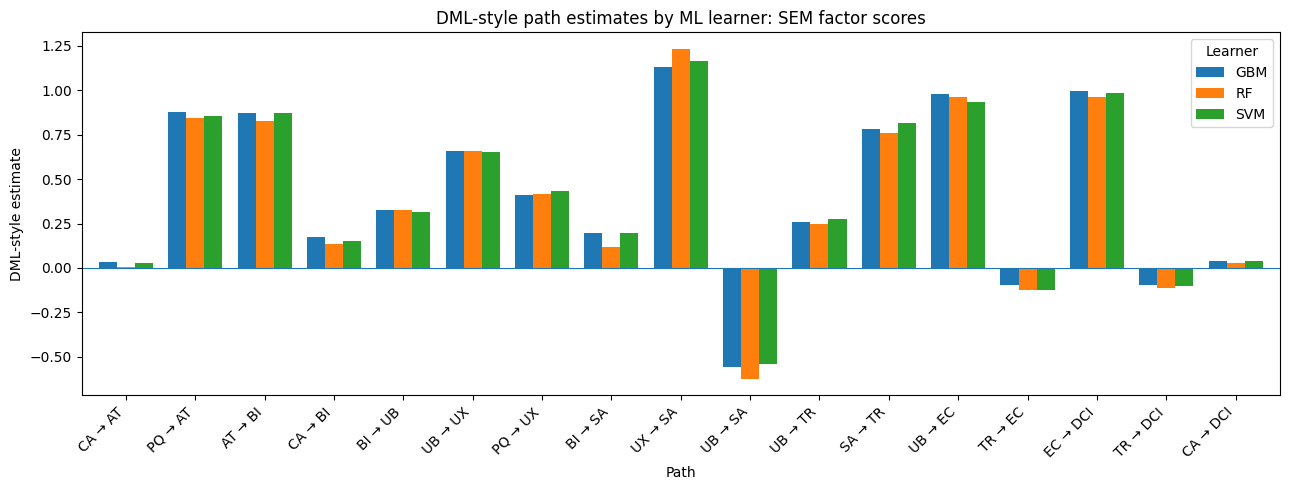

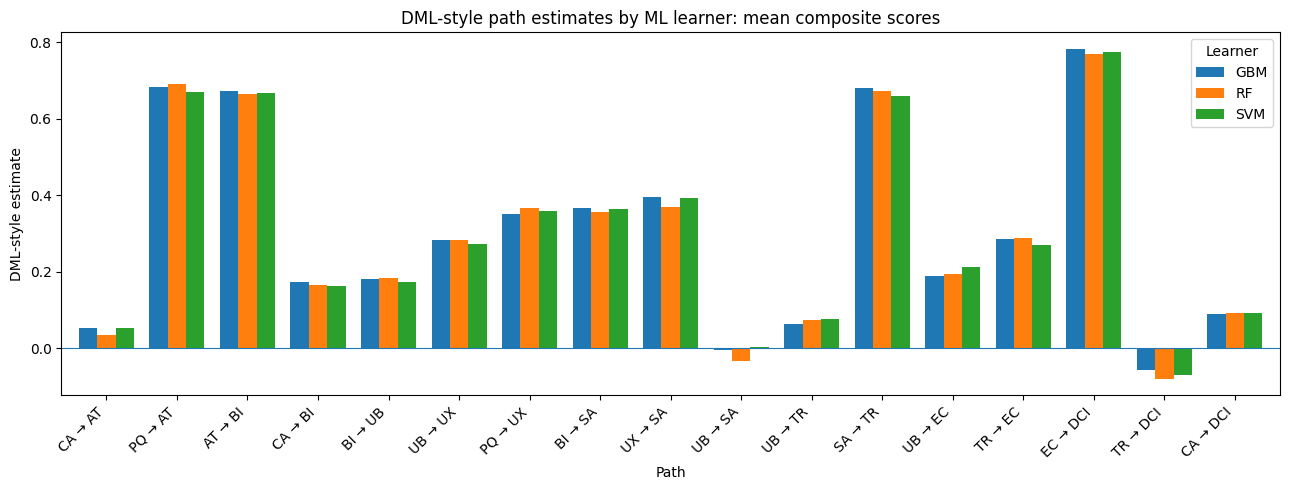

In [ ]:
def plot_dml_learner_comparison(ml_results, score_label, title):
    """Plot DML estimates by learner for one score source."""
    if ml_results is None or ml_results.empty:
        print(f'No learner-comparison results available for {score_label}.')
        return

    plot_df = ml_results[ml_results['Score source'] == score_label].copy()
    if plot_df.empty:
        print(f'No rows found for score source: {score_label}.')
        return

    pivot = plot_df.pivot_table(index='Path', columns='Learner', values='DML estimate', aggfunc='first')
    path_order = sem_structural_all[sem_structural_all['Model'] == ACTIVE_MODEL_KEY]['Path'].tolist()
    pivot = pivot.reindex([p for p in path_order if p in pivot.index])

    ax = pivot.plot(kind='bar', figsize=(13, 5), width=0.78)
    ax.axhline(0, linewidth=0.8)
    ax.set_ylabel('DML-style estimate')
    ax.set_title(title)
    ax.set_xlabel('Path')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


plot_dml_learner_comparison(
    factor_ml_dml_results,
    'SEM factor scores',
    'DML-style path estimates by ML learner: SEM factor scores'
)

plot_dml_learner_comparison(
    composite_ml_dml_results,
    'Mean composite scores',
    'DML-style path estimates by ML learner: mean composite scores'
)

## 11 Reverse-direction diagnostic checks [Stage 7: Directional robustness diagnostics]

### 11.1 Why run reverse-direction diagnostics?

Reverse-direction diagnostics are included to help researchers examine whether selected relationships are directionally sensitive under alternative path-level specifications. They are **not** tests of bidirectional causality, and they should not be used to mechanically reverse SEM paths.

In this public-release workbook, reverse-direction checks are treated as **researcher-configurable sensitivity checks**. A researcher may include a check for statistical, conceptual, or other practical reasons. Non-significance is therefore one possible reason for checking, but it is not the only reason, and it should not be treated as an automatic instruction to reverse or delete a path.

The rationale for checking can be grouped into three categories.

**Statistical reasons** arise when the empirical results suggest that a relationship deserves closer inspection. Examples include a non-significant hypothesised SEM path, an unexpected sign, a possible suppression pattern, instability across SEM factor scores and mean composite scores, sensitivity across RF/GBM/SVM learners, or large differences between SEM, OLS, and DML-style estimates.

**Conceptual reasons** arise when theory suggests that the reverse or reciprocal direction may be plausible. For example, trust may provide psychological safety for emotional connection, while emotional connection may also strengthen perceived trust. Similarly, usage may shape satisfaction, while satisfaction may encourage further usage.

**Other reasons** include reviewer concerns, mixed directions in prior literature, transparency, teaching value, or repository completeness.

A non-significant SEM path can be a useful trigger for diagnostic review, especially when deciding whether a path should be retained, revised, or removed. However, non-significance alone is not enough. In cross-sectional survey data, a non-significant path may reflect weak association, measurement limitations, restricted variance, multicollinearity, mediation, suppression, or insufficient statistical power. If both the hypothesised and reverse-direction checks are weak, this may support removal or revision when theory is also weak. If the reverse-direction check is significant, this does **not** prove the reverse causal direction; it indicates that the relationship may be directionally sensitive and requires further theoretical justification or stronger research designs, such as longitudinal or experimental data.

Public-release interpretation rule: reverse-direction diagnostics should be reported as **diagnostic sensitivity evidence only**. They do not establish causal reversal, reciprocal causality, or the superiority of the reverse path.


In [ ]:
reverse_diagnostic_guidelines = pd.DataFrame([
    {
        'reason_category': 'Statistical reasons',
        'reason_code': 'STAT01_non_significant_hypothesised_path',
        'reason': 'A theoretically expected SEM path is non-significant.',
        'when_to_use': 'Use as a diagnostic trigger when deciding whether a path should be retained, revised, or removed.',
        'caution': 'Non-significance is not an automatic reason to reverse or delete a path; it may reflect low power, mediation, suppression, multicollinearity, measurement limits, or restricted variance.'
    },
    {
        'reason_category': 'Statistical reasons',
        'reason_code': 'STAT02_unexpected_sign_or_suppression',
        'reason': 'The SEM path has an unexpected sign or appears to be affected by suppression after other variables are included.',
        'when_to_use': 'Use when a coefficient changes sign, becomes counter-theoretical, or differs materially from simpler bivariate or OLS patterns.',
        'caution': 'Interpret as conditional association, not causal contradiction.'
    },
    {
        'reason_category': 'Statistical reasons',
        'reason_code': 'STAT03_score_or_learner_sensitivity',
        'reason': 'The path behaves differently across SEM factor scores, composite scores, OLS, RF, GBM, or SVM.',
        'when_to_use': 'Use when robustness results are unstable across score representations or ML learners.',
        'caution': 'Sensitivity may indicate construct-score dependence, nuisance-model dependence, or model-specification dependence.'
    },
    {
        'reason_category': 'Statistical reasons',
        'reason_code': 'STAT04_zero_order_vs_conditional_difference',
        'reason': 'A strong bivariate relationship becomes weak, non-significant, or changes sign in the full model.',
        'when_to_use': 'Use when mediation, confounding, or suppression may explain the difference between simple and conditional estimates.',
        'caution': 'Report the control set and avoid interpreting the conditional estimate in isolation.'
    },
    {
        'reason_category': 'Conceptual reasons',
        'reason_code': 'CONC01_theoretical_reciprocal_plausibility',
        'reason': 'Prior theory or related empirical work makes both directions plausible.',
        'when_to_use': 'Use when the relationship may plausibly operate in either direction or as a feedback loop.',
        'caution': 'Do not infer bidirectional causality from cross-sectional data.'
    },
    {
        'reason_category': 'Conceptual reasons',
        'reason_code': 'CONC02_temporal_ambiguity',
        'reason': 'The survey is cross-sectional, so the temporal order is theoretically assumed rather than directly observed.',
        'when_to_use': 'Use for constructs that may co-evolve over time, such as usage, satisfaction, trust, and emotional connection.',
        'caution': 'Clarify that the robustness-baseline SEM direction remains theory-driven.'
    },
    {
        'reason_category': 'Conceptual reasons',
        'reason_code': 'CONC03_conceptual_proximity',
        'reason': 'The constructs are conceptually close and may be difficult to separate empirically.',
        'when_to_use': 'Use for near-outcome or relational constructs such as trust, emotional connection, and digital customer intimacy.',
        'caution': 'Check discriminant validity and avoid treating overlap as causal evidence.'
    },
    {
        'reason_category': 'Other reasons',
        'reason_code': 'OTHER01_reviewer_or_literature_concern',
        'reason': 'Prior literature or reviewer feedback raises a credible concern about path direction.',
        'when_to_use': 'Use when there is a specific scholarly reason to test an alternative direction.',
        'caution': 'Pre-specify where possible, or transparently label the check as post-hoc diagnostic.'
    },
    {
        'reason_category': 'Other reasons',
        'reason_code': 'OTHER02_transparency_or_teaching_value',
        'reason': 'The check improves transparency, teaching value, or repository completeness.',
        'when_to_use': 'Use in public notebooks or supplementary materials where readers may benefit from seeing how directional sensitivity is examined.',
        'caution': 'Keep the diagnostic clearly separated from the primary SEM hypothesis test.'
    }
])

display(reverse_diagnostic_guidelines)

sem_non_significant_paths_for_diagnostic_review = active_structural[
    active_structural['p_num'].notna() & (active_structural['p_num'] >= 0.05)
].copy()

if len(sem_non_significant_paths_for_diagnostic_review) > 0:
    sem_non_significant_paths_for_diagnostic_review['reason_category'] = 'Statistical reasons'
    sem_non_significant_paths_for_diagnostic_review['diagnostic_reason_code'] = 'STAT01_non_significant_hypothesised_path'
    sem_non_significant_paths_for_diagnostic_review['diagnostic_guidance'] = (
        'Consider additional diagnostics only if a reverse, reciprocal, mediated, or suppressed relationship is theoretically plausible. '
        'Do not reverse or remove this path based on non-significance alone. '
        'If both the hypothesised and diagnostic checks remain weak, this may add evidence for removal or revision when theory is also weak.'
    )
    display_cols = ['Path', 'Estimate', 'Std. Err', 'z-value', 'p-value', 'sig', 'diagnostic_reason_code', 'diagnostic_guidance']
    display(sem_non_significant_paths_for_diagnostic_review[[c for c in display_cols if c in sem_non_significant_paths_for_diagnostic_review.columns]])
else:
    print('No non-significant SEM structural paths were detected at p >= 0.05.')


,reason_category,reason_code,reason,when_to_use,caution
0,Statistical reasons,STAT01_non_significant_hypothesised_path,A theoretically expected SEM path is non-signi...,Use as a diagnostic trigger when deciding whet...,Non-significance is not an automatic reason to...
1,Statistical reasons,STAT02_unexpected_sign_or_suppression,The SEM path has an unexpected sign or appears...,"Use when a coefficient changes sign, becomes c...","Interpret as conditional association, not caus..."
2,Statistical reasons,STAT03_score_or_learner_sensitivity,The path behaves differently across SEM factor...,Use when robustness results are unstable acros...,Sensitivity may indicate construct-score depen...
3,Statistical reasons,STAT04_zero_order_vs_conditional_difference,"A strong bivariate relationship becomes weak, ...","Use when mediation, confounding, or suppressio...",Report the control set and avoid interpreting ...
4,Conceptual reasons,CONC01_theoretical_reciprocal_plausibility,Prior theory or related empirical work makes b...,Use when the relationship may plausibly operat...,Do not infer bidirectional causality from cros...
5,Conceptual reasons,CONC02_temporal_ambiguity,"The survey is cross-sectional, so the temporal...",Use for constructs that may co-evolve over tim...,Clarify that the robustness-baseline SEM direc...
6,Conceptual reasons,CONC03_conceptual_proximity,The constructs are conceptually close and may ...,Use for near-outcome or relational constructs ...,Check discriminant validity and avoid treating...
7,Other reasons,OTHER01_reviewer_or_literature_concern,Prior literature or reviewer feedback raises a...,Use when there is a specific scholarly reason ...,"Pre-specify where possible, or transparently l..."
8,Other reasons,OTHER02_transparency_or_teaching_value,"The check improves transparency, teaching valu...",Use in public notebooks or supplementary mater...,Keep the diagnostic clearly separated from the...


,Path,Estimate,Std. Err,z-value,p-value,sig,diagnostic_reason_code,diagnostic_guidance
0,CA → AT,0.037876,0.062276,0.608203,0.543053,n.s.,STAT01_non_significant_hypothesised_path,Consider additional diagnostics only if a reve...
13,TR → EC,-0.014009,0.095217,-0.147124,0.883034,n.s.,STAT01_non_significant_hypothesised_path,Consider additional diagnostics only if a reve...
16,CA → DCI,0.022292,0.040454,0.55104,0.581606,n.s.,STAT01_non_significant_hypothesised_path,Consider additional diagnostics only if a reve...


In [ ]:
BASE_REVERSE_DIAGNOSTIC_PAIRS = [
    {
        'pair_id': 'RD01',
        'pair': 'UB ↔ SA',
        'left': 'UB',
        'right': 'SA',
        'controls': ['BI', 'UX', 'Fintech Type'],
        'diagnostic_status': 'core_diagnostic',
        'reason_codes': 'STAT02_unexpected_sign_or_suppression; STAT04_zero_order_vs_conditional_difference; CONC02_temporal_ambiguity; CONC01_theoretical_reciprocal_plausibility',
        'statistical_reasons': 'The usage–satisfaction path may show unexpected signs, suppression, or differences between simple and conditional estimates.',
        'conceptual_reasons': 'Usage may shape satisfaction, while satisfied users may also use a platform more frequently in post-adoption settings.',
        'other_reasons': 'Useful for explaining post-adoption feedback and reviewer questions about the usage–satisfaction ordering.',
        'planned_interpretation': 'Diagnose whether usage behaviour and satisfaction show directional sensitivity; not evidence of bidirectional causality.'
    },
    {
        'pair_id': 'RD02',
        'pair': 'TR ↔ DCI',
        'left': 'TR',
        'right': 'DCI',
        'controls': ['EC', 'Fintech Type'],
        'diagnostic_status': 'core_diagnostic',
        'reason_codes': 'STAT01_non_significant_hypothesised_path; STAT02_unexpected_sign_or_suppression; CONC03_conceptual_proximity; CONC01_theoretical_reciprocal_plausibility',
        'statistical_reasons': 'The direct trust–DCI path may be weak, non-significant, negative, or suppression-sensitive once emotional connection is included.',
        'conceptual_reasons': 'Trust may support intimacy, while perceived intimacy may also reinforce trust in a digital relationship.',
        'other_reasons': 'Useful for clarifying that trust and digital intimacy are related but not identical relational constructs.',
        'planned_interpretation': 'Diagnose whether trust and intimacy show directionally sensitive or suppressive association.'
    },
    {
        'pair_id': 'RD03',
        'pair': 'UB ↔ TR',
        'left': 'UB',
        'right': 'TR',
        'controls': ['SA', 'Fintech Type'],
        'diagnostic_status': 'optional_diagnostic',
        'reason_codes': 'CONC01_theoretical_reciprocal_plausibility; CONC02_temporal_ambiguity; STAT03_score_or_learner_sensitivity',
        'statistical_reasons': 'The strength of usage–trust associations may vary across score representations or learners.',
        'conceptual_reasons': 'Usage may build trust through familiarity, while trust may also encourage continued or deeper usage.',
        'other_reasons': 'Useful as an optional check in cross-sectional post-adoption data.',
        'planned_interpretation': 'Diagnose whether trust may also explain usage behaviour and whether usage explains trust.'
    },
    {
        'pair_id': 'RD04',
        'pair': 'EC ↔ DCI',
        'left': 'EC',
        'right': 'DCI',
        'controls': ['TR', 'Fintech Type'],
        'diagnostic_status': 'core_diagnostic',
        'reason_codes': 'CONC01_theoretical_reciprocal_plausibility; CONC02_temporal_ambiguity; CONC03_conceptual_proximity',
        'statistical_reasons': 'Large or highly stable estimates may still require directional-sensitivity checking because the constructs are near outcomes.',
        'conceptual_reasons': 'Emotional connection and digital customer intimacy are closely related relational constructs; their assumed ordering should be checked cautiously.',
        'other_reasons': 'Useful for transparency and for distinguishing emotional connection from intimacy.',
        'planned_interpretation': 'Diagnose whether emotional connection and digital intimacy are directionally sensitive.'
    },
    {
        'pair_id': 'RD05',
        'pair': 'TR ↔ EC',
        'left': 'TR',
        'right': 'EC',
        'controls': ['UB', 'SA', 'Fintech Type'],
        'diagnostic_status': 'optional_diagnostic',
        'reason_codes': 'STAT01_non_significant_hypothesised_path; STAT02_unexpected_sign_or_suppression; CONC01_theoretical_reciprocal_plausibility; CONC03_conceptual_proximity',
        'statistical_reasons': 'The trust–emotion path may be non-significant, unexpectedly signed, or unstable once usage and satisfaction are included.',
        'conceptual_reasons': 'Trust may provide psychological safety for emotional connection, while emotional connection may also reinforce perceived trust.',
        'other_reasons': 'Useful for discussing the ordering of cognitive assurance and affective attachment.',
        'planned_interpretation': 'Diagnose whether trust and emotional connection show directional sensitivity; not evidence of reciprocal causality.'
    }
]

# Public-release default: add optional reverse diagnostics for non-significant SEM paths
# when they are not already covered by the predefined conceptual pairs.
# Researchers can set this to False if they want only the predefined diagnostic pairs.
ADD_OPTIONAL_NON_SIGNIFICANT_SEM_PATH_DIAGNOSTICS = True


def pair_key(left, right):
    return tuple(sorted([str(left), str(right)]))


def build_optional_ns_reverse_pairs(existing_pairs, ns_paths, dml_specs):
    existing_keys = {pair_key(p['left'], p['right']) for p in existing_pairs}
    optional_pairs = []
    ns_counter = 1

    for _, row in ns_paths.iterrows():
        left = row.get('rval')   # original SEM predictor
        right = row.get('lval')  # original SEM outcome
        if pd.isna(left) or pd.isna(right):
            continue
        key = pair_key(left, right)
        if key in existing_keys:
            continue

        matching_specs = [
            s for s in dml_specs
            if s.get('outcome') == right and s.get('focal_predictor') == left
        ]
        if matching_specs:
            controls = matching_specs[0].get('controls', OBSERVED_CONTROLS)
        else:
            controls = OBSERVED_CONTROLS

        optional_pairs.append({
            'pair_id': f'NS{ns_counter:02d}',
            'pair': f'{left} ↔ {right}',
            'left': left,
            'right': right,
            'controls': controls,
            'diagnostic_status': 'optional_diagnostic',
            'reason_codes': 'STAT01_non_significant_hypothesised_path; OTHER02_transparency_or_teaching_value',
            'statistical_reasons': (
                f'The hypothesised SEM path {left} → {right} is non-significant in the robustness-baseline SEM model. '
                'The optional reverse check can add evidence for retention, revision, or removal decisions.'
            ),
            'conceptual_reasons': (
                'Add or retain this check only if the reverse, reciprocal, mediated, or suppressed relationship is conceptually defensible.'
            ),
            'other_reasons': 'Included as a flexible public-release diagnostic option for transparent model-decision support.',
            'planned_interpretation': (
                'If both directions are weak, this may add evidence for removal or revision when theory is also weak. '
                'If the reverse direction is significant, interpret as directional sensitivity rather than causal reversal.'
            )
        })
        existing_keys.add(key)
        ns_counter += 1

    return optional_pairs


reverse_diagnostic_pairs = list(BASE_REVERSE_DIAGNOSTIC_PAIRS)

if ADD_OPTIONAL_NON_SIGNIFICANT_SEM_PATH_DIAGNOSTICS and len(sem_non_significant_paths_for_diagnostic_review) > 0:
    reverse_diagnostic_pairs.extend(
        build_optional_ns_reverse_pairs(
            existing_pairs=reverse_diagnostic_pairs,
            ns_paths=sem_non_significant_paths_for_diagnostic_review,
            dml_specs=dml_specs
        )
    )

reverse_diagnostic_pair_table = pd.DataFrame(reverse_diagnostic_pairs)
reverse_diagnostic_pair_table['interpretation_warning'] = 'Diagnostic only; not evidence of bidirectional or reverse causality.'
reverse_diagnostic_pair_table['reason_for_checking'] = (
    'Statistical: ' + reverse_diagnostic_pair_table['statistical_reasons'].fillna('') +
    ' | Conceptual: ' + reverse_diagnostic_pair_table['conceptual_reasons'].fillna('') +
    ' | Other: ' + reverse_diagnostic_pair_table['other_reasons'].fillna('')
)

display(reverse_diagnostic_pair_table)

reverse_diagnostic_specs = []
for pair in reverse_diagnostic_pairs:
    clean_controls = [c for c in pair['controls'] if c not in [pair['left'], pair['right']]]

    # Left -> Right
    reverse_diagnostic_specs.append({
        'path_id': f"{pair['pair_id']}A",
        'pair_id': pair['pair_id'],
        'pair': pair['pair'],
        'outcome': pair['right'],
        'focal_predictor': pair['left'],
        'controls': clean_controls,
        'direction_tested': f"{pair['left']} → {pair['right']}",
        'diagnostic_status': pair['diagnostic_status'],
        'reason_codes': pair['reason_codes'],
        'statistical_reasons': pair['statistical_reasons'],
        'conceptual_reasons': pair['conceptual_reasons'],
        'other_reasons': pair['other_reasons'],
        'reason_for_checking': (
            f"Statistical: {pair['statistical_reasons']} | "
            f"Conceptual: {pair['conceptual_reasons']} | "
            f"Other: {pair['other_reasons']}"
        ),
        'planned_interpretation': pair['planned_interpretation'],
        'interpretation_warning': 'Diagnostic only; not evidence of bidirectional or reverse causality.'
    })
    # Right -> Left
    reverse_diagnostic_specs.append({
        'path_id': f"{pair['pair_id']}B",
        'pair_id': pair['pair_id'],
        'pair': pair['pair'],
        'outcome': pair['left'],
        'focal_predictor': pair['right'],
        'controls': clean_controls,
        'direction_tested': f"{pair['right']} → {pair['left']}",
        'diagnostic_status': pair['diagnostic_status'],
        'reason_codes': pair['reason_codes'],
        'statistical_reasons': pair['statistical_reasons'],
        'conceptual_reasons': pair['conceptual_reasons'],
        'other_reasons': pair['other_reasons'],
        'reason_for_checking': (
            f"Statistical: {pair['statistical_reasons']} | "
            f"Conceptual: {pair['conceptual_reasons']} | "
            f"Other: {pair['other_reasons']}"
        ),
        'planned_interpretation': pair['planned_interpretation'],
        'interpretation_warning': 'Diagnostic only; not evidence of bidirectional or reverse causality.'
    })

reverse_diagnostic_spec_table = pd.DataFrame(reverse_diagnostic_specs)
display(reverse_diagnostic_spec_table)


def build_reverse_dml_master_results(score_datasets=SCORE_DATASETS, learners=DML_LEARNERS, specs=reverse_diagnostic_specs):
    rows = []
    for score_type, score_info in score_datasets.items():
        for learner in learners:
            for spec in specs:
                row = run_dml_style_single(
                    score_df=score_info['data'],
                    score_type=score_type,
                    score_label=score_info['label'],
                    learner_name=learner,
                    spec=spec,
                    analysis_type='reverse_diagnostic'
                )
                row['pair_id'] = spec['pair_id']
                row['pair'] = spec['pair']
                row['direction_tested'] = spec['direction_tested']
                row['diagnostic_status'] = spec['diagnostic_status']
                row['reason_codes'] = spec['reason_codes']
                row['statistical_reasons'] = spec['statistical_reasons']
                row['conceptual_reasons'] = spec['conceptual_reasons']
                row['other_reasons'] = spec['other_reasons']
                row['reason_for_checking'] = spec['reason_for_checking']
                row['planned_interpretation'] = spec['planned_interpretation']
                row['interpretation_warning'] = spec['interpretation_warning']
                row['causal_caution'] = 'Diagnostic only; does not establish bidirectional or reverse causality.'
                rows.append(row)
    return pd.DataFrame(rows)


reverse_direction_dml_master_all_scores_all_learners = build_reverse_dml_master_results()

# Keep requested columns early, while retaining diagnostic metadata.
reverse_ordered_cols = REQUESTED_DML_MASTER_COLUMNS + [
    c for c in reverse_direction_dml_master_all_scores_all_learners.columns
    if c not in REQUESTED_DML_MASTER_COLUMNS
]
reverse_direction_dml_master_all_scores_all_learners = reverse_direction_dml_master_all_scores_all_learners[reverse_ordered_cols]

print('Reverse-direction DML-style diagnostics: all score types × all learners × all diagnostic directions')
display(reverse_direction_dml_master_all_scores_all_learners.round(6))


def summarise_reverse_diagnostics(reverse_master):
    rows = []
    group_cols = [
        'score_type', 'score_label', 'pair_id', 'pair', 'path_id', 'direction_tested',
        'outcome', 'focal_predictor', 'controls', 'diagnostic_status', 'reason_codes',
        'statistical_reasons', 'conceptual_reasons', 'other_reasons', 'reason_for_checking',
        'interpretation_warning'
    ]
    for keys, g in reverse_master.groupby(group_cols, dropna=False):
        base = dict(zip(group_cols, keys))
        estimates = g.set_index('learner')['estimate'].to_dict()
        pvals = g.set_index('learner')['p_value'].to_dict()
        signs = np.sign(g['estimate'].dropna())
        nonzero_signs = [s for s in signs if s != 0]
        direction_stable = len(set(nonzero_signs)) <= 1 if nonzero_signs else False
        sig_count = int((g['p_value'] < 0.05).sum())
        base.update({
            'GBM estimate': estimates.get('GBM', np.nan),
            'GBM p': pvals.get('GBM', np.nan),
            'SVM estimate': estimates.get('SVM', np.nan),
            'SVM p': pvals.get('SVM', np.nan),
            'RF estimate': estimates.get('RF', np.nan),
            'RF p': pvals.get('RF', np.nan),
            'Sign stable across learners?': 'Yes' if direction_stable else 'Check',
            'Significant learners count': sig_count,
            'All learners significant?': 'Yes' if sig_count == len(g['learner'].unique()) else 'No',
            'Diagnostic interpretation': (
                'Diagnostic association is stable across learners.'
                if direction_stable and sig_count == len(g['learner'].unique())
                else 'Diagnostic evidence is learner- or significance-sensitive; interpret cautiously.'
            ),
            'Causal caution': 'Diagnostic only; does not establish bidirectional or reverse causality.'
        })
        rows.append(base)
    return pd.DataFrame(rows)


reverse_diagnostics_all = summarise_reverse_diagnostics(reverse_direction_dml_master_all_scores_all_learners)
factor_reverse_diagnostics = reverse_diagnostics_all[reverse_diagnostics_all['score_type'] == 'factor_score'].copy()
composite_reverse_diagnostics = reverse_diagnostics_all[reverse_diagnostics_all['score_type'] == 'composite_score'].copy()

print('Reverse-direction diagnostic summary using SEM factor scores:')
display(factor_reverse_diagnostics.round(6))

print('Reverse-direction diagnostic summary using mean composite scores:')
display(composite_reverse_diagnostics.round(6))


,pair_id,pair,left,right,controls,diagnostic_status,reason_codes,statistical_reasons,conceptual_reasons,other_reasons,planned_interpretation,interpretation_warning,reason_for_checking
0,RD01,UB ↔ SA,UB,SA,"[BI, UX, Fintech Type]",core_diagnostic,STAT02_unexpected_sign_or_suppression; STAT04_...,The usage–satisfaction path may show unexpecte...,"Usage may shape satisfaction, while satisfied ...",Useful for explaining post-adoption feedback a...,Diagnose whether usage behaviour and satisfact...,Diagnostic only; not evidence of bidirectional...,Statistical: The usage–satisfaction path may s...
1,RD02,TR ↔ DCI,TR,DCI,"[EC, Fintech Type]",core_diagnostic,STAT01_non_significant_hypothesised_path; STAT...,"The direct trust–DCI path may be weak, non-sig...","Trust may support intimacy, while perceived in...",Useful for clarifying that trust and digital i...,Diagnose whether trust and intimacy show direc...,Diagnostic only; not evidence of bidirectional...,Statistical: The direct trust–DCI path may be ...
2,RD03,UB ↔ TR,UB,TR,"[SA, Fintech Type]",optional_diagnostic,CONC01_theoretical_reciprocal_plausibility; CO...,The strength of usage–trust associations may v...,"Usage may build trust through familiarity, whi...",Useful as an optional check in cross-sectional...,Diagnose whether trust may also explain usage ...,Diagnostic only; not evidence of bidirectional...,Statistical: The strength of usage–trust assoc...
3,RD04,EC ↔ DCI,EC,DCI,"[TR, Fintech Type]",core_diagnostic,CONC01_theoretical_reciprocal_plausibility; CO...,Large or highly stable estimates may still req...,Emotional connection and digital customer inti...,Useful for transparency and for distinguishing...,Diagnose whether emotional connection and digi...,Diagnostic only; not evidence of bidirectional...,Statistical: Large or highly stable estimates ...
4,RD05,TR ↔ EC,TR,EC,"[UB, SA, Fintech Type]",optional_diagnostic,STAT01_non_significant_hypothesised_path; STAT...,"The trust–emotion path may be non-significant,...",Trust may provide psychological safety for emo...,Useful for discussing the ordering of cognitiv...,Diagnose whether trust and emotional connectio...,Diagnostic only; not evidence of bidirectional...,Statistical: The trust–emotion path may be non...
5,NS01,CA ↔ AT,CA,AT,"[PQ, Fintech Type]",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → AT is non-signi...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,"If both directions are weak, this may add evid...",Diagnostic only; not evidence of bidirectional...,Statistical: The hypothesised SEM path CA → AT...
6,NS02,CA ↔ DCI,CA,DCI,"[EC, TR, Fintech Type]",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → DCI is non-sign...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,"If both directions are weak, this may add evid...",Diagnostic only; not evidence of bidirectional...,Statistical: The hypothesised SEM path CA → DC...


,path_id,pair_id,pair,outcome,focal_predictor,controls,direction_tested,diagnostic_status,reason_codes,statistical_reasons,conceptual_reasons,other_reasons,reason_for_checking,planned_interpretation,interpretation_warning
0,RD01A,RD01,UB ↔ SA,SA,UB,"[BI, UX, Fintech Type]",UB → SA,core_diagnostic,STAT02_unexpected_sign_or_suppression; STAT04_...,The usage–satisfaction path may show unexpecte...,"Usage may shape satisfaction, while satisfied ...",Useful for explaining post-adoption feedback a...,Statistical: The usage–satisfaction path may s...,Diagnose whether usage behaviour and satisfact...,Diagnostic only; not evidence of bidirectional...
1,RD01B,RD01,UB ↔ SA,UB,SA,"[BI, UX, Fintech Type]",SA → UB,core_diagnostic,STAT02_unexpected_sign_or_suppression; STAT04_...,The usage–satisfaction path may show unexpecte...,"Usage may shape satisfaction, while satisfied ...",Useful for explaining post-adoption feedback a...,Statistical: The usage–satisfaction path may s...,Diagnose whether usage behaviour and satisfact...,Diagnostic only; not evidence of bidirectional...
2,RD02A,RD02,TR ↔ DCI,DCI,TR,"[EC, Fintech Type]",TR → DCI,core_diagnostic,STAT01_non_significant_hypothesised_path; STAT...,"The direct trust–DCI path may be weak, non-sig...","Trust may support intimacy, while perceived in...",Useful for clarifying that trust and digital i...,Statistical: The direct trust–DCI path may be ...,Diagnose whether trust and intimacy show direc...,Diagnostic only; not evidence of bidirectional...
3,RD02B,RD02,TR ↔ DCI,TR,DCI,"[EC, Fintech Type]",DCI → TR,core_diagnostic,STAT01_non_significant_hypothesised_path; STAT...,"The direct trust–DCI path may be weak, non-sig...","Trust may support intimacy, while perceived in...",Useful for clarifying that trust and digital i...,Statistical: The direct trust–DCI path may be ...,Diagnose whether trust and intimacy show direc...,Diagnostic only; not evidence of bidirectional...
4,RD03A,RD03,UB ↔ TR,TR,UB,"[SA, Fintech Type]",UB → TR,optional_diagnostic,CONC01_theoretical_reciprocal_plausibility; CO...,The strength of usage–trust associations may v...,"Usage may build trust through familiarity, whi...",Useful as an optional check in cross-sectional...,Statistical: The strength of usage–trust assoc...,Diagnose whether trust may also explain usage ...,Diagnostic only; not evidence of bidirectional...
5,RD03B,RD03,UB ↔ TR,UB,TR,"[SA, Fintech Type]",TR → UB,optional_diagnostic,CONC01_theoretical_reciprocal_plausibility; CO...,The strength of usage–trust associations may v...,"Usage may build trust through familiarity, whi...",Useful as an optional check in cross-sectional...,Statistical: The strength of usage–trust assoc...,Diagnose whether trust may also explain usage ...,Diagnostic only; not evidence of bidirectional...
6,RD04A,RD04,EC ↔ DCI,DCI,EC,"[TR, Fintech Type]",EC → DCI,core_diagnostic,CONC01_theoretical_reciprocal_plausibility; CO...,Large or highly stable estimates may still req...,Emotional connection and digital customer inti...,Useful for transparency and for distinguishing...,Statistical: Large or highly stable estimates ...,Diagnose whether emotional connection and digi...,Diagnostic only; not evidence of bidirectional...
7,RD04B,RD04,EC ↔ DCI,EC,DCI,"[TR, Fintech Type]",DCI → EC,core_diagnostic,CONC01_theoretical_reciprocal_plausibility; CO...,Large or highly stable estimates may still req...,Emotional connection and digital customer inti...,Useful for transparency and for distinguishing...,Statistical: Large or highly stable estimates ...,Diagnose whether emotional connection and digi...,Diagnostic only; not evidence of bidirectional...
8,RD05A,RD05,TR ↔ EC,EC,TR,"[UB, SA, Fintech Type]",TR → EC,optional_diagnostic,STAT01_non_significant_hypothesised_path; STAT...,"The trust–emotion path may be non-significant,...",Trust may provide psychological safety for emo...,Useful for discussing the ordering of cognitiv...,Statistical: The trust–emotion path may be non...,Diagnose whether trust and

Reverse-direction DML-style diagnostics: all score types × all learners × all diagnostic directions


,model_stage,score_type,learner,path_id,outcome,focal_predictor,controls,estimate,standard_error,t_value,p_value,significance_label,direction,analysis_type,model_stage_label,score_label,path,n,y_nuisance_rmse,y_nuisance_r2,d_nuisance_rmse,d_nuisance_r2,cross_fitting_folds,robust_cov_type,learner_config,pair_id,pair,direction_tested,diagnostic_status,reason_codes,statistical_reasons,conceptual_reasons,other_reasons,reason_for_checking,planned_interpretation,interpretation_warning,causal_caution
0,robustness_baseline_sem_model,factor_score,RF,RD01A,SA,UB,"BI, UX, Fintech Type",-0.624435,0.033115,-18.856443,0.000000,***,negative,reverse_diagnostic,Robustness-baseline SEM model,SEM factor scores,UB → SA,411,0.495232,0.754745,0.655014,0.570956,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam...",RD01,UB ↔ SA,UB → SA,core_diagnostic,STAT02_unexpected_sign_or_suppression; STAT04_...,The usage–satisfaction path may show unexpecte...,"Usage may shape satisfaction, while satisfied ...",Useful for explaining post-adoption feedback a...,Statistical: The usage–satisfaction path may s...,Diagnose whether usage behaviour and satisfact...,Diagnostic only; not evidence of bidirectional...,Diagnostic only; does not establish bidirectio...
1,robustness_baseline_sem_model,factor_score,RF,RD01B,UB,SA,"BI, UX, Fintech Type",-0.961966,0.080078,-12.012849,0.000000,***,negative,reverse_diagnostic,Robustness-baseline SEM model,SEM factor scores,SA → UB,411,0.617937,0.618154,0.519790,0.729818,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam...",RD01,UB ↔ SA,SA → UB,core_diagnostic,STAT02_unexpected_sign_or_suppression; STAT04_...,The usage–satisfaction path may show unexpecte...,"Usage may shape satisfaction, while satisfied ...",Useful for explaining post-adoption feedback a...,Statistical: The usage–satisfaction path may s...,Diagnose whether usage behaviour and satisfact...,Diagnostic only; not evidence of bidirectional...,Diagnostic only; does not establish bidirectio...
2,robustness_baseline_sem_model,factor_score,RF,RD02A,DCI,TR,"EC, Fintech Type",-0.117906,0.006796,-17.350155,0.000000,***,negative,reverse_diagnostic,Robustness-baseline SEM model,SEM factor scores,TR → DCI,411,0.152990,0.976594,0.912678,0.167019,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam...",RD02,TR ↔ DCI,TR → DCI,core_diagnostic,STAT01_non_significant_hypothesised_path; STAT...,"The direct trust–DCI path may be weak, non-sig...","Trust may support intimacy, while perceived in...",Useful for clarifying that trust and digital i...,Statistical: The direct trust–DCI path may be ...,Diagnose whether trust and intimacy show direc...,Diagnostic only; not evidence of bidirectional...,Diagnostic only; does not establish bidirectio...
3,robustness_baseline_sem_model,factor_score,RF,RD02B,TR,DCI,"EC, Fintech Type",-4.479278,0.273071,-16.403327,0.000000,***,negative,reverse_diagnostic,Robustness-baseline SEM model,SEM factor scores,DCI → TR,411,0.917463,0.158263,0.146811,0.978446,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam...",RD02,TR ↔ DCI,DCI → TR,core_diagnostic,STAT01_non_significant_hypothesised_path; STAT...,"The direct trust–DCI path may be weak, non-sig...","Trust may support intimacy, while perceived in...",Useful for clarifying that trust and digital i...,Statistical: The direct trust–DCI path may be ...,Diagnose whether trust and intimacy show direc...,Diagnostic only; not evidence of bidirectional...,Diagnostic only; does not establish bidirectio...
4,robustness_baseline_sem_model,factor_score,RF,RD03A,TR,UB,"SA, Fintech Type",0.249265,0.021004,11.867247,0.000000,***,positive,reverse_diagnostic,Robustness-baseline SEM model,SEM factor scores,UB → TR,411,0.408249,0.833333,0.984330,0.031095,3,HC1,"RandomForestRegressor(n_estimators=50, min_sam...",RD03,UB ↔ TR,UB → TR,optional_diagnostic,CONC01_theoretical_reciprocal_plausibility; CO...,The strength of usage–trust associations may v...,"Usage may build trust through familiarity, whi...",Useful as an o

Reverse-direction diagnostic summary using SEM factor scores:


,score_type,score_label,pair_id,pair,path_id,direction_tested,outcome,focal_predictor,controls,diagnostic_status,reason_codes,statistical_reasons,conceptual_reasons,other_reasons,reason_for_checking,interpretation_warning,GBM estimate,GBM p,SVM estimate,SVM p,RF estimate,RF p,Sign stable across learners?,Significant learners count,All learners significant?,Diagnostic interpretation,Causal caution
14,factor_score,SEM factor scores,NS01,CA ↔ AT,NS01A,CA → AT,AT,CA,"PQ, Fintech Type",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → AT is non-signi...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,Statistical: The hypothesised SEM path CA → AT...,Diagnostic only; not evidence of bidirectional...,0.033165,0.228790,0.026006,0.347239,0.002632,0.922202,Yes,0,No,Diagnostic evidence is learner- or significanc...,Diagnostic only; does not establish bidirectio...
15,factor_score,SEM factor scores,NS01,CA ↔ AT,NS01B,AT → CA,CA,AT,"PQ, Fintech Type",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → AT is non-signi...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,Statistical: The hypothesised SEM path CA → AT...,Diagnostic only; not evidence of bidirectional...,0.124991,0.146318,0.108729,0.270525,0.001887,0.983731,Yes,0,No,Diagnostic evidence is learner- or significanc...,Diagnostic only; does not establish bidirectio...
16,factor_score,SEM factor scores,NS02,CA ↔ DCI,NS02A,CA → DCI,DCI,CA,"EC, TR, Fintech Type",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → DCI is non-sign...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,Statistical: The hypothesised SEM path CA → DC...,Diagnostic only; not evidence of bidirectional...,0.038811,0.007308,0.038084,0.000142,0.028843,0.000004,Yes,3,Yes,Diagnostic association is stable across learners.,Diagnostic only; does not establish bidirectio...
17,factor_score,SEM factor scores,NS02,CA ↔ DCI,NS02B,DCI → CA,CA,DCI,"EC, TR, Fintech Type",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → DCI is non-sign...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,Statistical: The hypothesised SEM path CA → DC...,Diagnostic only; not evidence of bidirectional...,0.412228,0.023932,0.841408,0.003005,1.805269,0.000004,Yes,3,Yes,Diagnostic association is stable across learners.,Diagnostic only; does not establish bidirectio...
18,factor_score,SEM factor scores,RD01,UB ↔ SA,RD01A,UB → SA,SA,UB,"BI, UX, Fintech Type",core_diagnostic,STAT02_unexpected_sign_or_suppression; STAT04_...,The usage–satisfaction path may show unexpecte...,"Usage may shape satisfaction, while satisfied ...",Useful for explaining post-adoption feedback a...,Statistical: The usage–satisfaction path may s...,Diagnostic only; not evidence of bidirectional...,-0.557400,0.000000,-0.538570,0.000000,-0.624435,0.000000,Yes,3,Yes,Diagnostic association is stable across learners.,Diagnostic only; does not establish bidirectio...
19,factor_score,SEM factor scores,RD01,UB ↔ SA,RD01B,SA → UB,UB,SA,"BI, UX, Fintech Type",core_diagnostic,STAT02_unexpected_sign_or_suppression; STAT04_...,The usage–satisfaction path may show unexpecte...,"Usage may shape satisfaction, while satisfied ...",Useful for explaining post-adoption feedback a...,Statistical: The usage–satisfaction path may s...,Diagnostic only; not evidence of bidirectional...,-0.770385,0.000000,-0.683425,0.000001,-0.961966,0.000000,Yes,3,Yes,Diagnostic association is stable across learners.,Diagnostic only; does not establish bidirectio...
20,factor_score,SEM factor scores,RD02,TR ↔ DCI,RD02A,TR → DCI,DCI,TR,"EC, Fintech Type",core_diagnostic,STAT01_non_significant_hypothesised_path; STA

Reverse-direction diagnostic summary using mean composite scores:


,score_type,score_label,pair_id,pair,path_id,direction_tested,outcome,focal_predictor,controls,diagnostic_status,reason_codes,statistical_reasons,conceptual_reasons,other_reasons,reason_for_checking,interpretation_warning,GBM estimate,GBM p,SVM estimate,SVM p,RF estimate,RF p,Sign stable across learners?,Significant learners count,All learners significant?,Diagnostic interpretation,Causal caution
0,composite_score,Mean composite scores,NS01,CA ↔ AT,NS01A,CA → AT,AT,CA,"PQ, Fintech Type",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → AT is non-signi...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,Statistical: The hypothesised SEM path CA → AT...,Diagnostic only; not evidence of bidirectional...,0.054468,0.153040,0.053156,0.167560,0.035680,0.356360,Yes,0,No,Diagnostic evidence is learner- or significanc...,Diagnostic only; does not establish bidirectio...
1,composite_score,Mean composite scores,NS01,CA ↔ AT,NS01B,AT → CA,CA,AT,"PQ, Fintech Type",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → AT is non-signi...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,Statistical: The hypothesised SEM path CA → AT...,Diagnostic only; not evidence of bidirectional...,0.091879,0.137939,0.099777,0.133838,0.060543,0.348766,Yes,0,No,Diagnostic evidence is learner- or significanc...,Diagnostic only; does not establish bidirectio...
2,composite_score,Mean composite scores,NS02,CA ↔ DCI,NS02A,CA → DCI,DCI,CA,"EC, TR, Fintech Type",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → DCI is non-sign...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,Statistical: The hypothesised SEM path CA → DC...,Diagnostic only; not evidence of bidirectional...,0.090581,0.003590,0.092011,0.001250,0.093825,0.000780,Yes,3,Yes,Diagnostic association is stable across learners.,Diagnostic only; does not establish bidirectio...
3,composite_score,Mean composite scores,NS02,CA ↔ DCI,NS02B,DCI → CA,CA,DCI,"EC, TR, Fintech Type",optional_diagnostic,STAT01_non_significant_hypothesised_path; OTHE...,The hypothesised SEM path CA → DCI is non-sign...,"Add or retain this check only if the reverse, ...",Included as a flexible public-release diagnost...,Statistical: The hypothesised SEM path CA → DC...,Diagnostic only; not evidence of bidirectional...,0.214502,0.005949,0.235447,0.002845,0.273562,0.000442,Yes,3,Yes,Diagnostic association is stable across learners.,Diagnostic only; does not establish bidirectio...
4,composite_score,Mean composite scores,RD01,UB ↔ SA,RD01A,UB → SA,SA,UB,"BI, UX, Fintech Type",core_diagnostic,STAT02_unexpected_sign_or_suppression; STAT04_...,The usage–satisfaction path may show unexpecte...,"Usage may shape satisfaction, while satisfied ...",Useful for explaining post-adoption feedback a...,Statistical: The usage–satisfaction path may s...,Diagnostic only; not evidence of bidirectional...,-0.004949,0.920389,0.004499,0.932878,-0.033834,0.484814,Check,0,No,Diagnostic evidence is learner- or significanc...,Diagnostic only; does not establish bidirectio...
5,composite_score,Mean composite scores,RD01,UB ↔ SA,RD01B,SA → UB,UB,SA,"BI, UX, Fintech Type",core_diagnostic,STAT02_unexpected_sign_or_suppression; STAT04_...,The usage–satisfaction path may show unexpecte...,"Usage may shape satisfaction, while satisfied ...",Useful for explaining post-adoption feedback a...,Statistical: The usage–satisfaction path may s...,Diagnostic only; not evidence of bidirectional...,0.000343,0.995831,-0.004265,0.947168,-0.040323,0.543145,Check,0,No,Diagnostic evidence is learner- or significanc...,Diagnostic only; does not establish bidirectio...
6,composite_score,Mean composite scores,RD02,TR ↔ DCI,RD02A,TR → DCI,DCI,TR,"EC, Fintech Type",core_diagnostic,STA

## 12 Integrated SEM–OLS–DML robustness summary [Stage 8: Integrated robustness interpretation]

This section brings together the evidence needed for final structural model refinement decisions. The purpose is not to let OLS or DML overrule SEM. Instead, the goal is to assess whether selected path-level associations remain stable across alternative estimation strategies.

In [ ]:
def build_comparison_table(sem_structural_all, ols_results, dml_results, score_label):
    sem_part = sem_structural_all[sem_structural_all['Model'] == ACTIVE_MODEL_KEY].copy()
    sem_part = sem_part.rename(columns={
        'Estimate': 'SEM estimate',
        'p_num': 'SEM p',
        'sig': 'SEM sig'
    })[['Path', 'SEM estimate', 'SEM p', 'SEM sig']]

    ols_part = ols_results[['Path', 'OLS coef', 'OLS p', 'OLS sig']].copy()
    dml_part = dml_results[['Path', 'DML estimate', 'DML p', 'DML sig']].copy()

    comparison = sem_part.merge(ols_part, on='Path', how='left').merge(dml_part, on='Path', how='left')
    comparison.insert(0, 'model_stage', ACTIVE_MODEL_KEY)
    comparison.insert(1, 'Model stage label', ACTIVE_MODEL_LABEL)
    comparison.insert(2, 'Score source', score_label)
    comparison.insert(3, 'DML learner used', 'RF')

    comparison['SEM direction'] = comparison['SEM estimate'].apply(direction_from_estimate)
    comparison['OLS direction'] = comparison['OLS coef'].apply(direction_from_estimate)
    comparison['DML direction'] = comparison['DML estimate'].apply(direction_from_estimate)
    comparison['Direction stable across all?'] = np.where(
        (comparison['SEM direction'] == comparison['OLS direction']) &
        (comparison['SEM direction'] == comparison['DML direction']),
        'Yes', 'Check'
    )

    def interpret(row):
        if row['Direction stable across all?'] == 'Yes' and row['SEM sig'] != 'n.s.' and row['OLS sig'] != 'n.s.' and row['DML sig'] != 'n.s.':
            return 'Robust: direction and significance are consistent across SEM, OLS, and RF-DML checks.'
        if row['Direction stable across all?'] == 'Yes':
            return 'Partially robust: direction is stable, but at least one method is not statistically significant.'
        return 'Needs review: sign or significance differs across methods.'

    comparison['Robustness interpretation'] = comparison.apply(interpret, axis=1)
    return comparison


factor_comparison = build_comparison_table(
    sem_structural_all,
    factor_ols_results,
    factor_dml_results,
    'SEM factor scores'
)

composite_comparison = build_comparison_table(
    sem_structural_all,
    composite_ols_results,
    composite_dml_results,
    'Mean composite scores'
)

sem_ols_dml_comparison_all = pd.concat(
    [factor_comparison, composite_comparison],
    ignore_index=True
)

print('SEM–OLS–RF-DML comparison using SEM factor scores:')
display(factor_comparison.round(6))
print('SEM–OLS–RF-DML comparison using mean composite scores:')
display(composite_comparison.round(6))


def validate_rf_dml_consistency(master_df, comparisons, sensitivity_summaries):
    """Confirm main RF-DML values exactly match RF values in learner-sensitivity tables."""
    validation_rows = []
    score_type_map = {
        'SEM factor scores': 'factor_score',
        'Mean composite scores': 'composite_score'
    }
    for score_label, comparison in comparisons.items():
        score_type = score_type_map[score_label]
        summary = sensitivity_summaries[score_label]

        master_rf = master_df[
            (master_df['score_type'] == score_type) &
            (master_df['learner'] == 'RF')
        ].copy()
        master_rf = master_rf[['path', 'estimate', 'p_value']].rename(columns={
            'path': 'Path',
            'estimate': 'Master RF estimate',
            'p_value': 'Master RF p'
        })

        comp_rf = comparison[['Path', 'DML estimate', 'DML p']].rename(columns={
            'DML estimate': 'Comparison RF estimate',
            'DML p': 'Comparison RF p'
        })

        sens_rf = summary[['Path', 'RF estimate', 'RF p']].rename(columns={
            'RF estimate': 'Sensitivity RF estimate',
            'RF p': 'Sensitivity RF p'
        })

        check = master_rf.merge(comp_rf, on='Path', how='outer').merge(sens_rf, on='Path', how='outer')
        check.insert(0, 'model_stage', ACTIVE_MODEL_KEY)
        check.insert(1, 'Model stage label', ACTIVE_MODEL_LABEL)
        check.insert(2, 'Score source', score_label)
        check['Comparison estimate exact match'] = check['Master RF estimate'] == check['Comparison RF estimate']
        check['Comparison p exact match'] = check['Master RF p'] == check['Comparison RF p']
        check['Sensitivity estimate exact match'] = check['Master RF estimate'] == check['Sensitivity RF estimate']
        check['Sensitivity p exact match'] = check['Master RF p'] == check['Sensitivity RF p']
        check['All RF values exact match'] = (
            check['Comparison estimate exact match'] &
            check['Comparison p exact match'] &
            check['Sensitivity estimate exact match'] &
            check['Sensitivity p exact match']
        )
        validation_rows.append(check)

    validation = pd.concat(validation_rows, ignore_index=True)
    if not validation['All RF values exact match'].all():
        display(validation)
        raise AssertionError('RF-DML values differ between master, comparison, and learner-sensitivity tables.')
    return validation


rf_dml_consistency_validation = validate_rf_dml_consistency(
    dml_master_results_all_scores_all_learners,
    comparisons={
        'SEM factor scores': factor_comparison,
        'Mean composite scores': composite_comparison
    },
    sensitivity_summaries={
        'SEM factor scores': factor_ml_dml_summary,
        'Mean composite scores': composite_ml_dml_summary
    }
)

print('RF-DML consistency validation passed: main comparison RF values exactly match learner-sensitivity RF values.')
display(rf_dml_consistency_validation)

SEM–OLS–RF-DML comparison using SEM factor scores:


,model_stage,Model stage label,Score source,DML learner used,Path,SEM estimate,SEM p,SEM sig,OLS coef,OLS p,OLS sig,DML estimate,DML p,DML sig,SEM direction,OLS direction,DML direction,Direction stable across all?,Robustness interpretation
0,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,CA → AT,0.037876,0.543053,n.s.,0.006942,0.796612,n.s.,0.002632,0.922202,n.s.,positive,positive,positive,Yes,"Partially robust: direction is stable, but at ..."
1,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,PQ → AT,1.102151,0.000000,***,0.893863,0.000000,***,0.845232,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
2,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,AT → BI,0.924247,0.000000,***,0.886133,0.000000,***,0.829511,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
3,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,CA → BI,0.214789,0.001381,**,0.142426,0.000000,***,0.135005,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
4,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,BI → UB,0.084512,0.005016,**,0.333570,0.000000,***,0.324881,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
5,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,UB → UX,0.933708,0.000344,***,0.635982,0.000000,***,0.659298,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
6,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,PQ → UX,0.260525,0.000005,***,0.431152,0.000000,***,0.417751,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
7,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,BI → SA,0.182477,0.009899,**,0.122408,0.000000,***,0.115424,0.000032,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
8,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,UX → SA,2.380199,0.000004,***,1.351471,0.000000,***,1.232650,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
9,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,RF,UB → SA,-2.042860,0.002807,**,-0.771641,0.000000,***,-0.624435,0.000000,***,negative,negative,negative,Yes,Robust: direction and significance are consist...


SEM–OLS–RF-DML comparison using mean composite scores:


,model_stage,Model stage label,Score source,DML learner used,Path,SEM estimate,SEM p,SEM sig,OLS coef,OLS p,OLS sig,DML estimate,DML p,DML sig,SEM direction,OLS direction,DML direction,Direction stable across all?,Robustness interpretation
0,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,CA → AT,0.037876,0.543053,n.s.,0.044642,0.233613,n.s.,0.035680,0.356360,n.s.,positive,positive,positive,Yes,"Partially robust: direction is stable, but at ..."
1,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,PQ → AT,1.102151,0.000000,***,0.694624,0.000000,***,0.691168,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
2,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,AT → BI,0.924247,0.000000,***,0.684698,0.000000,***,0.665147,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
3,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,CA → BI,0.214789,0.001381,**,0.158357,0.000065,***,0.165313,0.000025,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
4,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,BI → UB,0.084512,0.005016,**,0.189725,0.000114,***,0.183562,0.000152,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
5,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,UB → UX,0.933708,0.000344,***,0.289846,0.000000,***,0.282063,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
6,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,PQ → UX,0.260525,0.000005,***,0.362371,0.000000,***,0.365915,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
7,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,BI → SA,0.182477,0.009899,**,0.352463,0.000000,***,0.357374,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
8,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,UX → SA,2.380199,0.000004,***,0.358497,0.000000,***,0.370428,0.000000,***,positive,positive,positive,Yes,Robust: direction and significance are consist...
9,robustness_baseline_sem_model,Robustness-baseline SEM model,Mean composite scores,RF,UB → SA,-2.042860,0.002807,**,-0.023771,0.634929,n.s.,-0.033834,0.484814,n.s.,negative,negative,negative,Yes,"Partially robust: direction is stable, but at ..."


RF-DML consistency validation passed: main comparison RF values exactly match learner-sensitivity RF values.


,model_stage,Model stage label,Score source,Path,Master RF estimate,Master RF p,Comparison RF estimate,Comparison RF p,Sensitivity RF estimate,Sensitivity RF p,Comparison estimate exact match,Comparison p exact match,Sensitivity estimate exact match,Sensitivity p exact match,All RF values exact match
0,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,AT → BI,0.829511,2.337322e-296,0.829511,2.337322e-296,0.829511,2.337322e-296,True,True,True,True,True
1,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,BI → SA,0.115424,3.214265e-05,0.115424,3.214265e-05,0.115424,3.214265e-05,True,True,True,True,True
2,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,BI → UB,0.324881,1.546736e-10,0.324881,1.546736e-10,0.324881,1.546736e-10,True,True,True,True,True
3,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,CA → AT,0.002632,9.222021e-01,0.002632,9.222021e-01,0.002632,9.222021e-01,True,True,True,True,True
4,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,CA → BI,0.135005,2.658316e-15,0.135005,2.658316e-15,0.135005,2.658316e-15,True,True,True,True,True
5,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,CA → DCI,0.028843,4.205927e-06,0.028843,4.205927e-06,0.028843,4.205927e-06,True,True,True,True,True
6,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,EC → DCI,0.962336,0.000000e+00,0.962336,0.000000e+00,0.962336,0.000000e+00,True,True,True,True,True
7,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,PQ → AT,0.845232,1.645949e-176,0.845232,1.645949e-176,0.845232,1.645949e-176,True,True,True,True,True
8,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,PQ → UX,0.417751,7.961687e-28,0.417751,7.961687e-28,0.417751,7.961687e-28,True,True,True,True,True
9,robustness_baseline_sem_model,Robustness-baseline SEM model,SEM factor scores,SA → TR,0.759330,1.898521e-273,0.759330,1.898521e-273,0.759330,1.898521e-273,True,True,True,True,True


### 12.1 Model-decision evidence table [Stage 8]

In [ ]:
def build_model_decision_evidence_summary(factor_comp, composite_comp, factor_sens, composite_sens):
    rows = []
    all_paths = factor_comp['Path'].tolist()
    for path in all_paths:
        f = factor_comp[factor_comp['Path'] == path].iloc[0]
        c_df = composite_comp[composite_comp['Path'] == path]
        c = c_df.iloc[0] if not c_df.empty else pd.Series(dtype=object)
        fs_df = factor_sens[factor_sens['Path'] == path]
        cs_df = composite_sens[composite_sens['Path'] == path]
        fs = fs_df.iloc[0] if not fs_df.empty else pd.Series(dtype=object)
        cs = cs_df.iloc[0] if not cs_df.empty else pd.Series(dtype=object)

        sem_sig = f.get('SEM sig')
        factor_direction_stable = f.get('Direction stable across all?')
        composite_direction_stable = c.get('Direction stable across all?', np.nan)
        factor_all_learners_sig = fs.get('All learners significant?', np.nan)
        composite_all_learners_sig = cs.get('All learners significant?', np.nan)

        if sem_sig != 'n.s.' and factor_direction_stable == 'Yes' and f.get('OLS sig') != 'n.s.' and f.get('DML sig') != 'n.s.':
            evidence_label = 'Strong retention evidence'
        elif sem_sig == 'n.s.' and factor_direction_stable == 'Yes' and (f.get('OLS sig') != 'n.s.' or f.get('DML sig') != 'n.s.' or factor_all_learners_sig == 'Yes'):
            evidence_label = 'Mixed evidence; theory review needed'
        elif sem_sig == 'n.s.' and f.get('OLS sig') == 'n.s.' and f.get('DML sig') == 'n.s.':
            evidence_label = 'Weak empirical support'
        else:
            evidence_label = 'Check method sensitivity'

        rows.append({
            'Path': path,
            'SEM estimate': f.get('SEM estimate'),
            'SEM p': f.get('SEM p'),
            'SEM sig': sem_sig,
            'Factor-score OLS sig': f.get('OLS sig'),
            'Factor-score RF-DML sig': f.get('DML sig'),
            'Factor-score direction stable?': factor_direction_stable,
            'Factor-score all DML learners significant?': factor_all_learners_sig,
            'Composite-score direction stable?': composite_direction_stable,
            'Composite-score all DML learners significant?': composite_all_learners_sig,
            'Evidence label': evidence_label,
            'Decision guidance': 'Use this as decision support only; final structural model refinement decisions should consider theory, construct validity, SEM fit, parsimony, and robustness evidence together.'
        })
    return pd.DataFrame(rows)


model_decision_evidence_summary = build_model_decision_evidence_summary(
    factor_comparison,
    composite_comparison,
    factor_ml_dml_summary,
    composite_ml_dml_summary
)

display(model_decision_evidence_summary.round(6))

,Path,SEM estimate,SEM p,SEM sig,Factor-score OLS sig,Factor-score RF-DML sig,Factor-score direction stable?,Factor-score all DML learners significant?,Composite-score direction stable?,Composite-score all DML learners significant?,Evidence label,Decision guidance
0,CA → AT,0.037876,0.543053,n.s.,n.s.,n.s.,Yes,No,Yes,No,Weak empirical support,Use this as decision support only; final struc...
1,PQ → AT,1.102151,0.000000,***,***,***,Yes,Yes,Yes,Yes,Strong retention evidence,Use this as decision support only; final struc...
2,AT → BI,0.924247,0.000000,***,***,***,Yes,Yes,Yes,Yes,Strong retention evidence,Use this as decision support only; final struc...
3,CA → BI,0.214789,0.001381,**,***,***,Yes,Yes,Yes,Yes,Strong retention evidence,Use this as decision support only; final struc...
4,BI → UB,0.084512,0.005016,**,***,***,Yes,Yes,Yes,Yes,Strong retention evidence,Use this as decision support only; final struc...
5,UB → UX,0.933708,0.000344,***,***,***,Yes,Yes,Yes,Yes,Strong retention evidence,Use this as decision support only; final struc...
6,PQ → UX,0.260525,0.000005,***,***,***,Yes,Yes,Yes,Yes,Strong retention evidence,Use this as decision support only; final struc...
7,BI → SA,0.182477,0.009899,**,***,***,Yes,Yes,Yes,Yes,Strong retention evidence,Use this as decision support only; final struc...
8,UX → SA,2.380199,0.000004,***,***,***,Yes,Yes,Yes,Yes,Strong retention evidence,Use this as decision support only; final struc...
9,UB → SA,-2.042860,0.002807,**,***,***,Yes,Yes,Yes,No,Strong retention evidence,Use this as decision support only; final struc...


### 12.2 Interpretation of integrated SEM–OLS–DML robustness summary [Stage 8]

The integrated table should be read as an evidence summary for model judgement:

- paths that are significant and directionally stable across SEM, OLS, and RF-DML are strong candidates for retention;
- paths that are weak in SEM but supported by OLS/DML should be reviewed theoretically rather than removed automatically;
- paths that are weak or unstable across multiple diagnostics require cautious interpretation and possible model revision;
- DML evidence should be interpreted as supplementary robustness evidence, not as a standard SEM procedure or a replacement for SEM.

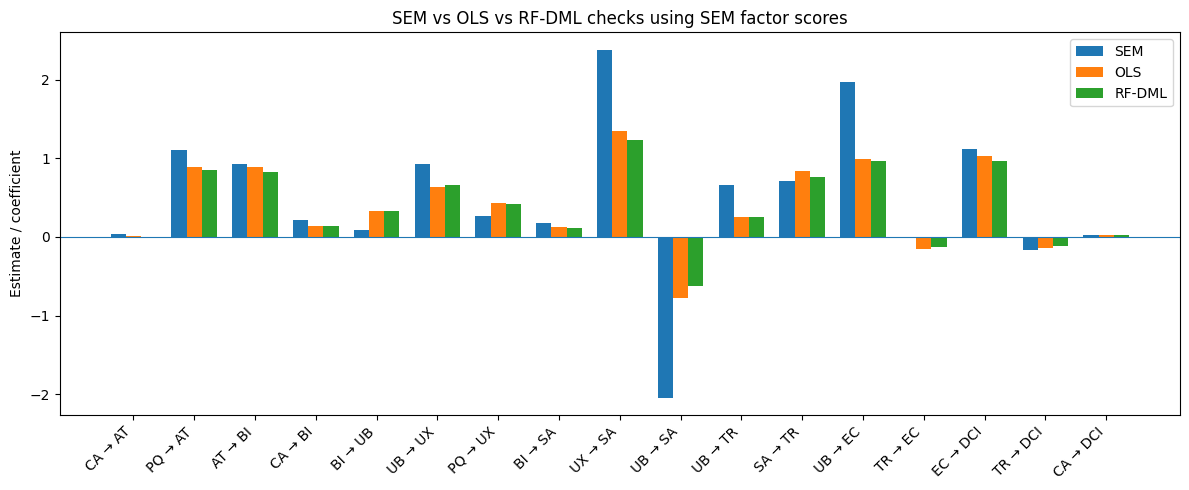

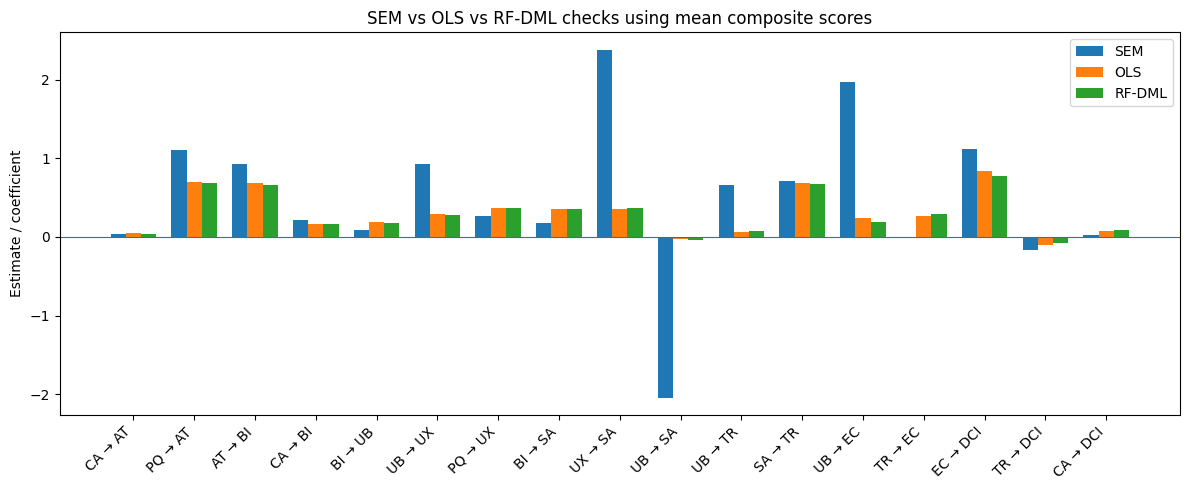

In [ ]:
def plot_comparison(comparison, title):
    plot_df = comparison.copy()
    x = np.arange(len(plot_df))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, plot_df['SEM estimate'], width=width, label='SEM')
    ax.bar(x, plot_df['OLS coef'], width=width, label='OLS')
    ax.bar(x + width, plot_df['DML estimate'], width=width, label='RF-DML')
    ax.axhline(0, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['Path'], rotation=45, ha='right')
    ax.set_ylabel('Estimate / coefficient')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_comparison(factor_comparison, 'SEM vs OLS vs RF-DML checks using SEM factor scores')
plot_comparison(composite_comparison, 'SEM vs OLS vs RF-DML checks using mean composite scores')

### 12.3 How to read the regenerated comparison tables [Stage 8]

The main comparison table uses RF-DML because RF is the default learner used for the concise SEM–OLS–DML table. The broader learner-sensitivity tables show whether the DML-style estimates are stable across RF, GBM, and SVM.

The most important comparison is not exact coefficient equality. SEM, OLS, and DML estimate related but not identical quantities. The key question is whether the direction and broad statistical pattern of each theoretically important path remain stable.

## 13 Reporting guidance and public-release checklist [Stage 8: Reporting interpretation]

Recommended reporting language:

> The robustness-baseline SEM model provides the primary latent-variable test of the hypothesised relationships after measurement refinement and before final structural path evaluation. OLS and DML-style analyses were conducted as supplementary robustness checks using SEM-derived factor scores and mean composite scores. These analyses examine whether robustness-baseline path-level associations remain directionally and statistically stable under alternative estimation strategies. They are not intended to replace SEM, validate the measurement model, or establish causal effects from cross-sectional data.

Public-release checklist:

- Confirm the dataset path and output folder before running.
- Run the notebook from top to bottom in a fresh runtime.
- Confirm that `robustness_baseline_sem_endogenous_r2.csv` has been regenerated and that its values are derived from standardised residual variances.
- Confirm that `dml_rf_consistency_validation.csv` reports exact RF consistency.
- Use `repository_file_manifest.csv` to check that all repository files were regenerated.
- Review privacy and ethics requirements before releasing respondent-level CSV files.


## 14 Exporting reproducible tables and figures [Repository package for Stages 1–8]

In [ ]:
print("Outputs will be saved to:")
print(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXPORT_ANALYSIS_DATASET = True  # Review privacy/ethics requirements before public repository release.
export_manifest_rows = []


def export_df(df_obj, filename, description, paper_stage, index=False):
    path = os.path.join(OUTPUT_DIR, filename)
    df_obj.to_csv(path, index=index)
    export_manifest_rows.append({
        'File': filename,
        'Type': 'csv',
        'Paper stage': paper_stage,
        'Description': description,
        'Rows': len(df_obj) if hasattr(df_obj, '__len__') else np.nan,
        'Columns': len(df_obj.columns) if hasattr(df_obj, 'columns') else np.nan
    })
    return path


def register_file(filename, file_type, description, paper_stage):
    export_manifest_rows.append({
        'File': filename,
        'Type': file_type,
        'Paper stage': paper_stage,
        'Description': description,
        'Rows': np.nan,
        'Columns': np.nan
    })


def dict_to_item_map(d, map_name):
    rows = []
    for construct, items in d.items():
        for order, item in enumerate(items, start=1):
            rows.append({'Map': map_name, 'Construct': construct, 'Item order': order, 'Indicator': item})
    return pd.DataFrame(rows)


# -------------------------------------------------------------------
# 14.1 Repository metadata and Stage 1 diagnostics
# -------------------------------------------------------------------
stage_map_df = pd.DataFrame([
    {'Paper stage': 'Stage 1', 'Notebook section': 'Sections 3–4', 'Purpose': 'Initial conceptual model, item diagnostics, reliability checks, redundancy checks, and documented item-level decisions'},
    {'Paper stage': 'Stage 2', 'Notebook section': 'Sections 3–5', 'Purpose': 'Measurement-model refinement and retained-indicator specification'},
    {'Paper stage': 'Stage 3', 'Notebook section': 'Sections 5–6', 'Purpose': 'Robustness-baseline SEM estimation, fit, structural-path assessment, explained variance, and diagram'},
    {'Paper stage': 'Stage 4', 'Notebook section': 'Section 7', 'Purpose': 'Construct-score construction from the refined measurement model'},
    {'Paper stage': 'Stage 5', 'Notebook section': 'Sections 8–9', 'Purpose': 'SEM-to-regression path translation and control-vector logic'},
    {'Paper stage': 'Stage 6', 'Notebook section': 'Section 8', 'Purpose': 'OLS robustness benchmark'},
    {'Paper stage': 'Stage 7', 'Notebook section': 'Sections 9–11', 'Purpose': 'DML-style robustness, learner sensitivity, and reverse-direction diagnostics'},
    {'Paper stage': 'Stage 8', 'Notebook section': 'Sections 12–13', 'Purpose': 'Integrated robustness interpretation and final structural path evaluation'}
])

software_versions_df = pd.DataFrame([
    {'Component': 'Python', 'Version': sys.version.replace('\n', ' ')},
    {'Component': 'Platform', 'Version': platform.platform()},
    {'Component': 'pandas', 'Version': pd.__version__},
    {'Component': 'numpy', 'Version': np.__version__},
    {'Component': 'scikit-learn', 'Version': sklearn.__version__},
    {'Component': 'statsmodels', 'Version': statsmodels.__version__},
])
try:
    import semopy as semopy_module
    software_versions_df = pd.concat([
        software_versions_df,
        pd.DataFrame([{'Component': 'semopy', 'Version': getattr(semopy_module, '__version__', 'unknown')}])
    ], ignore_index=True)
except Exception:
    pass

method_settings_df = pd.DataFrame([
    {'Setting': 'MODEL_VARIANT_TO_RUN', 'Value': MODEL_VARIANT_TO_RUN, 'Description': 'Active SEM specification used for public-release outputs'},
    {'Setting': 'ACTIVE_MODEL_LABEL', 'Value': ACTIVE_MODEL_LABEL, 'Description': 'Human-readable active model label'},
    {'Setting': 'ROBUST_COV_TYPE', 'Value': ROBUST_COV_TYPE, 'Description': 'Robust covariance estimator for OLS and residual regression'},
    {'Setting': 'RF_CONFIG', 'Value': 'RandomForestRegressor(n_estimators=50, min_samples_leaf=5, random_state=42)', 'Description': 'Single RF configuration used everywhere for RF-DML'},
    {'Setting': 'DML_N_SPLITS', 'Value': DML_N_SPLITS, 'Description': 'Cross-fitting folds'},
    {'Setting': 'DML_RANDOM_STATE', 'Value': DML_RANDOM_STATE, 'Description': 'Random seed for reproducibility'},
    {'Setting': 'DML_LEARNERS', 'Value': ', '.join(DML_LEARNERS), 'Description': 'Nuisance learners included in the master DML table'},
    {'Setting': 'DML_SCORE_TYPES', 'Value': ', '.join(SCORE_DATASETS.keys()), 'Description': 'Score representations included in the master DML table'},
    {'Setting': 'ADD_OPTIONAL_NON_SIGNIFICANT_SEM_PATH_DIAGNOSTICS', 'Value': ADD_OPTIONAL_NON_SIGNIFICANT_SEM_PATH_DIAGNOSTICS, 'Description': 'Whether optional reverse diagnostics are added for non-significant SEM paths not already covered by predefined diagnostic pairs'}
])

analysis_dataset_overview_df = pd.DataFrame([{
    'Rows': df.shape[0],
    'Columns': df.shape[1],
    'Input data path': data_path,
    'Output directory': OUTPUT_DIR,
    'Active model key': ACTIVE_MODEL_KEY,
    'Active model label': ACTIVE_MODEL_LABEL,
    'Includes derived DCI2_3_avg': 'DCI2_3_avg' in df.columns
}])

analysis_variable_dictionary_df = pd.DataFrame({
    'Variable': df.columns,
    'Dtype': [str(df[c].dtype) for c in df.columns],
    'Missing values': [int(df[c].isna().sum()) for c in df.columns],
    'Unique values': [int(df[c].nunique(dropna=True)) for c in df.columns]
})

construct_item_maps_df = pd.concat([
    dict_to_item_map(constructs_original, 'original'),
    dict_to_item_map(constructs_final, 'retained_for_robustness_baseline_model')
], ignore_index=True)

model_specs_df = pd.DataFrame([
    {
        'Model key': 'robustness_baseline_sem_model',
        'Model label': 'Robustness-baseline SEM model',
        'Default public-release model?': 'Yes',
        'Model specification': ROBUSTNESS_BASELINE_SEM_MODEL_SPEC
    },
    {
        'Model key': 'alternative_retained_model',
        'Model label': 'Alternative retained model',
        'Default public-release model?': 'No',
        'Model specification': ALTERNATIVE_RETAINED_SEM_MODEL_SPEC
    }
])

export_df(stage_map_df, 'paper_stage_map.csv', 'Mapping between method stages and notebook sections', 'Stages 1–8')
export_df(software_versions_df, 'software_versions.csv', 'Software and package versions used in the notebook runtime', 'Repository metadata')
export_df(method_settings_df, 'method_settings.csv', 'OLS and DML-style reproducibility settings', 'Repository metadata')
export_df(analysis_dataset_overview_df, 'analysis_dataset_overview.csv', 'Dataset and output-directory overview', 'Input / Stages 1–8')
export_df(analysis_variable_dictionary_df, 'analysis_variable_dictionary.csv', 'Variable-level dtype, missingness, and uniqueness summary', 'Input / Stage 1')
export_df(construct_item_maps_df, 'construct_item_maps.csv', 'Original and retained construct-item maps', 'Stage 1')
export_df(decision_log, 'item_diagnostic_decision_log.csv', 'Documented item-level diagnostic and refinement decisions', 'Stage 1')
export_df(reliability_df, 'reliability_original_constructs.csv', 'Reliability diagnostics for original construct definitions and diagnostic datasets', 'Stage 1')
export_df(final_reliability_df, 'reliability_retained_constructs.csv', 'Reliability diagnostics for retained item sets', 'Stage 1')
export_df(redundancy_df, 'dci_redundancy_pairs.csv', 'DCI item redundancy diagnostics', 'Stage 1')

if EXPORT_ANALYSIS_DATASET:
    export_df(df.reset_index(drop=True), 'analysis_dataset_with_derived_indicators.csv', 'Cleaned analysis dataset with derived indicators used by the notebook; review ethics/privacy before public release', 'Input / Stages 1–8')


# -------------------------------------------------------------------
# 14.2 Export SEM outputs for the robustness-baseline SEM model
# -------------------------------------------------------------------
export_df(model_specs_df, 'sem_model_specifications.csv', 'SEM syntax for the default robustness-baseline SEM model and optional alternative model', 'Stages 2–3')

active_params = sem_outputs[ACTIVE_MODEL_KEY]['params'].copy()
export_df(active_params, 'robustness_baseline_sem_model_parameters.csv', 'All SEM parameters for the active robustness-baseline SEM model', 'Stages 2–3')

try:
    active_std_params = sem_models[ACTIVE_MODEL_KEY].inspect(std_est=True)
    export_df(active_std_params, 'robustness_baseline_sem_model_parameters_standardized.csv', 'Standardised SEM parameters for the active robustness-baseline SEM model', 'Stages 2–3')
except Exception as e:
    print(f'Could not export standardised parameters: {e}')

try:
    active_fit_stats = sem_outputs[ACTIVE_MODEL_KEY]['stats'].copy()
    export_df(active_fit_stats, 'robustness_baseline_sem_model_fit_stats.csv', 'Fit statistics for the active robustness-baseline SEM model', 'Stages 2–3')
except Exception as e:
    print(f'Could not export fit statistics: {e}')

robustness_baseline_sem_structural_paths = sem_structural_all[sem_structural_all['Model'] == ACTIVE_MODEL_KEY].copy()
export_df(robustness_baseline_sem_structural_paths, 'robustness_baseline_sem_structural_paths.csv', 'Structural SEM path estimates for the robustness-baseline SEM model', 'Stage 3')
export_df(sem_structural_all, 'sem_structural_paths.csv', 'Structural SEM paths for the active model', 'Stage 3')
export_df(sem_fit_overview, 'sem_fit_overview.csv', 'SEM fit overview for the active model', 'Stages 2–3')
export_df(sem_endogenous_r2, 'robustness_baseline_sem_endogenous_r2.csv', 'SEM R² values for endogenous constructs in the robustness-baseline SEM model, derived from standardised residual variances', 'Stage 3')


# -------------------------------------------------------------------
# 14.3 Export construct scores and path-level robustness specifications
# -------------------------------------------------------------------
factor_scores_export = factor_scores.copy()
factor_scores_export.insert(0, 'row_id', np.arange(len(factor_scores_export)))
composite_scores_export = composite_scores.copy()
composite_scores_export.insert(0, 'row_id', np.arange(len(composite_scores_export)))

export_df(factor_scores_export, 'sem_factor_scores.csv', 'SEM factor scores extracted from the active robustness-baseline SEM model', 'Stage 4')
export_df(composite_scores_export, 'mean_composite_scores.csv', 'Mean composite construct scores based on retained item sets', 'Stage 4')
export_df(factor_score_z.reset_index(drop=True), 'sem_factor_scores_standardized.csv', 'Standardised SEM factor-score dataset used for OLS/DML', 'Stage 4')
export_df(composite_score_z.reset_index(drop=True), 'mean_composite_scores_standardized.csv', 'Standardised composite-score dataset used for OLS/DML', 'Stage 4')
export_df(path_mapping_table, 'path_mapping_for_ols_dml.csv', 'Path-level Y, focal D, and control X mapping for OLS/DML checks', 'Stage 5')
export_df(dml_spec_table, 'dml_specification_table.csv', 'DML specification table derived from the robustness-baseline SEM paths', 'Stage 5')


# -------------------------------------------------------------------
# 14.4 Export OLS, DML, learner sensitivity, reverse diagnostics, and comparison tables
# -------------------------------------------------------------------
export_df(factor_ols_results, 'factor_score_ols_results.csv', 'OLS robustness results using SEM factor scores', 'Stage 6')
export_df(composite_ols_results, 'composite_score_ols_results.csv', 'OLS robustness results using mean composite scores', 'Stage 6')
export_df(vif_results, 'factor_score_ols_vif_results.csv', 'Optional VIF diagnostics for factor-score OLS predictor/control sets', 'Stage 6')

export_df(dml_master_results_all_scores_all_learners, 'dml_master_results_all_scores_all_learners.csv', 'Master DML table across score types, RF/GBM/SVM learners, and robustness-baseline SEM paths', 'Stage 7')
export_df(factor_dml_results, 'factor_score_rf_dml_results.csv', 'RF-DML results using SEM factor scores; derived from master DML table', 'Stage 7')
export_df(composite_dml_results, 'composite_score_rf_dml_results.csv', 'RF-DML results using mean composite scores; derived from master DML table', 'Stage 7')
export_df(factor_ml_dml_results, 'factor_score_dml_learner_comparison_results.csv', 'RF/GBM/SVM DML-style results using SEM factor scores; derived from master DML table', 'Stage 7')
export_df(composite_ml_dml_results, 'composite_score_dml_learner_comparison_results.csv', 'RF/GBM/SVM DML-style results using mean composite scores; derived from master DML table', 'Stage 7')
export_df(factor_ml_dml_summary, 'factor_score_dml_learner_sensitivity_summary.csv', 'Learner-sensitivity summary using SEM factor scores', 'Stage 7')
export_df(composite_ml_dml_summary, 'composite_score_dml_learner_sensitivity_summary.csv', 'Learner-sensitivity summary using mean composite scores', 'Stage 7')
export_df(dml_learner_sensitivity_summary_all, 'dml_learner_sensitivity_summary_all.csv', 'Combined learner-sensitivity summary across score types', 'Stage 7')

export_df(reverse_diagnostic_guidelines, 'reverse_direction_diagnostic_guidelines.csv', 'Guidelines for selecting and interpreting reverse-direction diagnostic checks, grouped into statistical, conceptual, and other reasons', 'Stage 7')
export_df(sem_non_significant_paths_for_diagnostic_review, 'sem_non_significant_paths_for_diagnostic_review.csv', 'Non-significant SEM structural paths flagged for theory-informed diagnostic review', 'Stage 7')
export_df(reverse_diagnostic_pair_table, 'reverse_direction_diagnostic_pair_rationale.csv', 'Reverse-diagnostic pair rationale with diagnostic status and statistical, conceptual, and other reasons', 'Stage 7')
export_df(reverse_diagnostic_spec_table, 'reverse_direction_diagnostic_specs.csv', 'Planned/theory-sensitive reverse-direction diagnostic specifications', 'Stage 7')
export_df(reverse_direction_dml_master_all_scores_all_learners, 'reverse_direction_dml_master_all_scores_all_learners.csv', 'Master reverse-direction DML diagnostics across score types and RF/GBM/SVM learners', 'Stage 7')
export_df(factor_reverse_diagnostics, 'reverse_direction_diagnostics_factor_scores.csv', 'Reverse-direction diagnostic summary using SEM factor scores across RF/GBM/SVM', 'Stage 7')
export_df(composite_reverse_diagnostics, 'reverse_direction_diagnostics_composite_scores.csv', 'Reverse-direction diagnostic summary using mean composite scores across RF/GBM/SVM', 'Stage 7')
export_df(reverse_diagnostics_all, 'reverse_direction_diagnostics_all.csv', 'Combined reverse-direction diagnostic summary across score representations and learners', 'Stage 7')

export_df(rf_dml_consistency_validation, 'dml_rf_consistency_validation.csv', 'Validation confirming RF-DML values match exactly across master, main comparison, and learner-sensitivity tables', 'Stage 7 / Stage 8')
export_df(factor_comparison, 'factor_score_sem_ols_dml_comparison.csv', 'SEM–OLS–RF-DML comparison using SEM factor scores', 'Stage 8')
export_df(factor_comparison, 'sem_ols_dml_comparison.csv', 'Primary SEM–OLS–RF-DML comparison table using SEM factor scores', 'Stage 8')
export_df(composite_comparison, 'composite_score_sem_ols_dml_comparison.csv', 'SEM–OLS–RF-DML comparison using mean composite scores', 'Stage 8')
export_df(sem_ols_dml_comparison_all, 'sem_ols_dml_comparison_all_score_types.csv', 'Combined SEM–OLS–RF-DML comparison across score types', 'Stage 8')
export_df(model_decision_evidence_summary, 'model_decision_evidence_summary.csv', 'Integrated evidence table for final structural model refinement decisions', 'Stage 8')


# -------------------------------------------------------------------
# 14.5 Save diagrams and coefficient-comparison figures
# -------------------------------------------------------------------
def save_path_diagram(edges, title, save_path, edge_labels=None, figsize=(11, 5.8)):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    pos = {
        'PQ': (0, 2), 'CA': (0, 0), 'AT': (1, 2), 'BI': (2, 1), 'UB': (3, 1),
        'UX': (4, 2), 'SA': (5, 1), 'TR': (6, 1), 'EC': (5, -0.5), 'DCI': (7, 0.2)
    }
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, node_size=2400, node_color='white', edgecolors='black', linewidths=1.4)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=18, width=1.8, connectionstyle='arc3,rad=0.04')
    if edge_labels:
        nx.draw_networkx_edge_labels(
            G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.53,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none')
        )
    plt.title(title, fontsize=14, pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()


robustness_baseline_diagram = os.path.join(OUTPUT_DIR, 'robustness_baseline_sem_path_diagram.png')
save_path_diagram(active_edges, f'{ACTIVE_MODEL_LABEL}: structural path diagram', robustness_baseline_diagram, edge_labels=edge_labels)
register_file('robustness_baseline_sem_path_diagram.png', 'png', 'Tested SEM path diagram with path estimates', 'Stage 3')


def save_comparison_plot(comparison, title, save_path):
    plot_df = comparison.copy()
    x = np.arange(len(plot_df))
    width = 0.25
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, plot_df['SEM estimate'], width=width, label='SEM')
    ax.bar(x, plot_df['OLS coef'], width=width, label='OLS')
    ax.bar(x + width, plot_df['DML estimate'], width=width, label='RF-DML')
    ax.axhline(0, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['Path'], rotation=45, ha='right')
    ax.set_ylabel('Estimate / coefficient')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()


factor_comparison_plot = os.path.join(OUTPUT_DIR, 'sem_ols_dml_coefficient_comparison_factor_scores.png')
composite_comparison_plot = os.path.join(OUTPUT_DIR, 'sem_ols_dml_coefficient_comparison_composite_scores.png')
save_comparison_plot(factor_comparison, 'SEM vs OLS vs RF-DML checks using SEM factor scores', factor_comparison_plot)
save_comparison_plot(composite_comparison, 'SEM vs OLS vs RF-DML checks using mean composite scores', composite_comparison_plot)
register_file('sem_ols_dml_coefficient_comparison_factor_scores.png', 'png', 'Coefficient comparison figure using SEM factor scores', 'Stage 8')
register_file('sem_ols_dml_coefficient_comparison_composite_scores.png', 'png', 'Coefficient comparison figure using mean composite scores', 'Stage 8')


def save_dml_learner_comparison(ml_results, score_label, title, save_path):
    if ml_results is None or ml_results.empty:
        print(f'Skipping learner-comparison figure for {score_label}; no results available.')
        return False
    plot_df = ml_results[ml_results['Score source'] == score_label].copy()
    if plot_df.empty:
        print(f'Skipping learner-comparison figure for {score_label}; no results available.')
        return False
    pivot = plot_df.pivot_table(index='Path', columns='Learner', values='DML estimate', aggfunc='first')
    path_order = sem_structural_all[sem_structural_all['Model'] == ACTIVE_MODEL_KEY]['Path'].tolist()
    pivot = pivot.reindex([p for p in path_order if p in pivot.index])
    ax = pivot.plot(kind='bar', figsize=(13, 5), width=0.78)
    ax.axhline(0, linewidth=0.8)
    ax.set_ylabel('DML-style estimate')
    ax.set_title(title)
    ax.set_xlabel('Path')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()
    return True


factor_learner_plot = os.path.join(OUTPUT_DIR, 'factor_score_dml_learner_comparison.png')
composite_learner_plot = os.path.join(OUTPUT_DIR, 'composite_score_dml_learner_comparison.png')
if save_dml_learner_comparison(factor_ml_dml_results, 'SEM factor scores', 'DML-style path estimates by ML learner: SEM factor scores', factor_learner_plot):
    register_file('factor_score_dml_learner_comparison.png', 'png', 'DML learner-comparison figure using SEM factor scores', 'Stage 7')
if save_dml_learner_comparison(composite_ml_dml_results, 'Mean composite scores', 'DML-style path estimates by ML learner: mean composite scores', composite_learner_plot):
    register_file('composite_score_dml_learner_comparison.png', 'png', 'DML learner-comparison figure using mean composite scores', 'Stage 7')


# -------------------------------------------------------------------
# 14.6 Export manifest after all CSVs and figures have been registered
# -------------------------------------------------------------------
repository_manifest_df = pd.DataFrame(export_manifest_rows)
repository_manifest_df.to_csv(os.path.join(OUTPUT_DIR, 'repository_file_manifest.csv'), index=False)

print(f'Exported reproducible tables and figures to: {OUTPUT_DIR}')
print('Files exported:')
for name in sorted(os.listdir(OUTPUT_DIR)):
    print(' -', name)

Outputs will be saved to:
/content/drive/My Drive/Colab Notebooks/dci/sem_ols_dml_outputs_v7_0_2
Exported reproducible tables and figures to: /content/drive/My Drive/Colab Notebooks/dci/sem_ols_dml_outputs_v7_0_2
Files exported:
 - analysis_dataset_overview.csv
 - analysis_dataset_with_derived_indicators.csv
 - analysis_variable_dictionary.csv
 - composite_score_dml_learner_comparison.png
 - composite_score_dml_learner_comparison_results.csv
 - composite_score_dml_learner_sensitivity_summary.csv
 - composite_score_ols_results.csv
 - composite_score_rf_dml_results.csv
 - composite_score_sem_ols_dml_comparison.csv
 - construct_item_maps.csv
 - dci_redundancy_pairs.csv
 - dml_learner_sensitivity_summary_all.csv
 - dml_master_results_all_scores_all_learners.csv
 - dml_rf_consistency_validation.csv
 - dml_specification_table.csv
 - factor_score_dml_learner_comparison.png
 - factor_score_dml_learner_comparison_results.csv
 - factor_score_dml_learner_sensitivity_summary.csv
 - factor_score_ol